In [2]:
import pandas as pd

In [3]:
df_crops = pd.read_csv('Corn vs Soybeans, Irrigated vs Non-Irrigated, County Level, 2000-2024.csv', on_bad_lines='skip')
df_drought = pd.read_csv('Drought data.csv', on_bad_lines='skip')

In [4]:
print("Crop data")
print(df_crops.head())
print("\nDrought Data")
print(df_drought.head())

Crop data
  Program  Year Period Geo Level     State  State ANSI Ag District  \
0  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
1  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
2  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
3  SURVEY  2024   YEAR    COUNTY  DELAWARE          10         NaN   
4  SURVEY  2024   YEAR    COUNTY  DELAWARE          10    SOUTHERN   

   Ag District Code          County County ANSI Commodity  \
0                99  OTHER COUNTIES         NaN      CORN   
1                99  OTHER COUNTIES         NaN      CORN   
2                99  OTHER COUNTIES         NaN  SOYBEANS   
3                99  OTHER COUNTIES         NaN  SOYBEANS   
4                80          SUSSEX           5      CORN   

                                           Data Item  Value  
0  CORN, GRAIN, IRRIGATED - YIELD, MEASURED IN BU...  217.9  
1  CORN, GRAIN, NON-IRRIGATED - YIELD, MEASURED I...  154.2  
2  SOYBEANS, IRR

In [5]:
df_crop_yields = df_crops[['Year', 'State', 'Commodity', 'Data Item', 'Value']]
# Gets the average yield in bushels/acre per state
df_crop_yields = df_crop_yields.groupby(['Year', 'State', 'Data Item'])['Value'].mean().reset_index()
# Create a pivot table to combine different data items (e.g. irrigated and non-irrigated) into the same row
df_crop_yields = df_crop_yields.pivot_table(index=['Year', 'State'], columns='Data Item', values='Value').reset_index()
df_crop_yields.columns.name = None
df_crop_yields.columns = ['Year', 'State', 'Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']
# Use State abbreviations
state_abbrev = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA', 'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE',
    'FLORIDA': 'FL', 'GEORGIA': 'GA', 'HAWAII': 'HI', 'IDAHO': 'ID',
    'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS',
    'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK',
    'OREGON': 'OR', 'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC',
    'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN', 'TEXAS': 'TX', 'UTAH': 'UT',
    'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA', 'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI', 'WYOMING': 'WY'
}
df_crop_yields['State'] = df_crop_yields['State'].map(state_abbrev)
print(df_crop_yields.head())

   Year State  Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  \
0  2000    WY             NaN          60.000000            NaN   
1  2007    AR             NaN                NaN      39.214286   
2  2007    CO      147.238095          56.794118            NaN   
3  2007    KS      167.000000         102.458333      50.384615   
4  2008    AR             NaN                NaN      40.166667   

   Soy_NonIrrigated  
0               NaN  
1         22.678571  
2               NaN  
3         32.960000  
4         27.727273  


In [6]:
#print(df_drought.columns)
df_drought_index = df_drought[['MapDate', 'State', 'D0', 'D1', 'D2', 'D3', 'D4']]
df_drought_index['Drought Index'] = (df_drought['D0'] * 1 + df_drought['D1'] * 2 + df_drought['D2'] * 3 + df_drought['D3'] * 4 + df_drought['D4'] * 5)
df_drought_index.drop(columns=['D0', 'D1', 'D2', 'D3', 'D4'], inplace=True)
df_drought_index['Year'] = df_drought_index['MapDate'].astype(str).str[:4].astype(int)  
df_drought_index.drop(columns=['MapDate'], inplace=True)  
df_drought_index = df_drought_index[['Year', 'State', 'Drought Index']]
df_drought_index = df_drought_index.groupby(['Year', 'State'])['Drought Index'].mean().reset_index()
# Get rid of Puerto Rico and DC
df_drought_index = df_drought_index[~df_drought_index['State'].isin(['DC', 'PR'])]
print(df_drought_index)

      Year State  Drought Index
0     2000    AK       2.308551
1     2000    AL     681.266472
2     2000    AR     228.927572
3     2000    AZ     104.065872
4     2000    CA       7.367921
...    ...   ...            ...
1399  2026    VT     124.284714
1400  2026    WA     130.533128
1401  2026    WI      92.511370
1402  2026    WV      77.340618
1403  2026    WY     370.614754

[1350 rows x 3 columns]


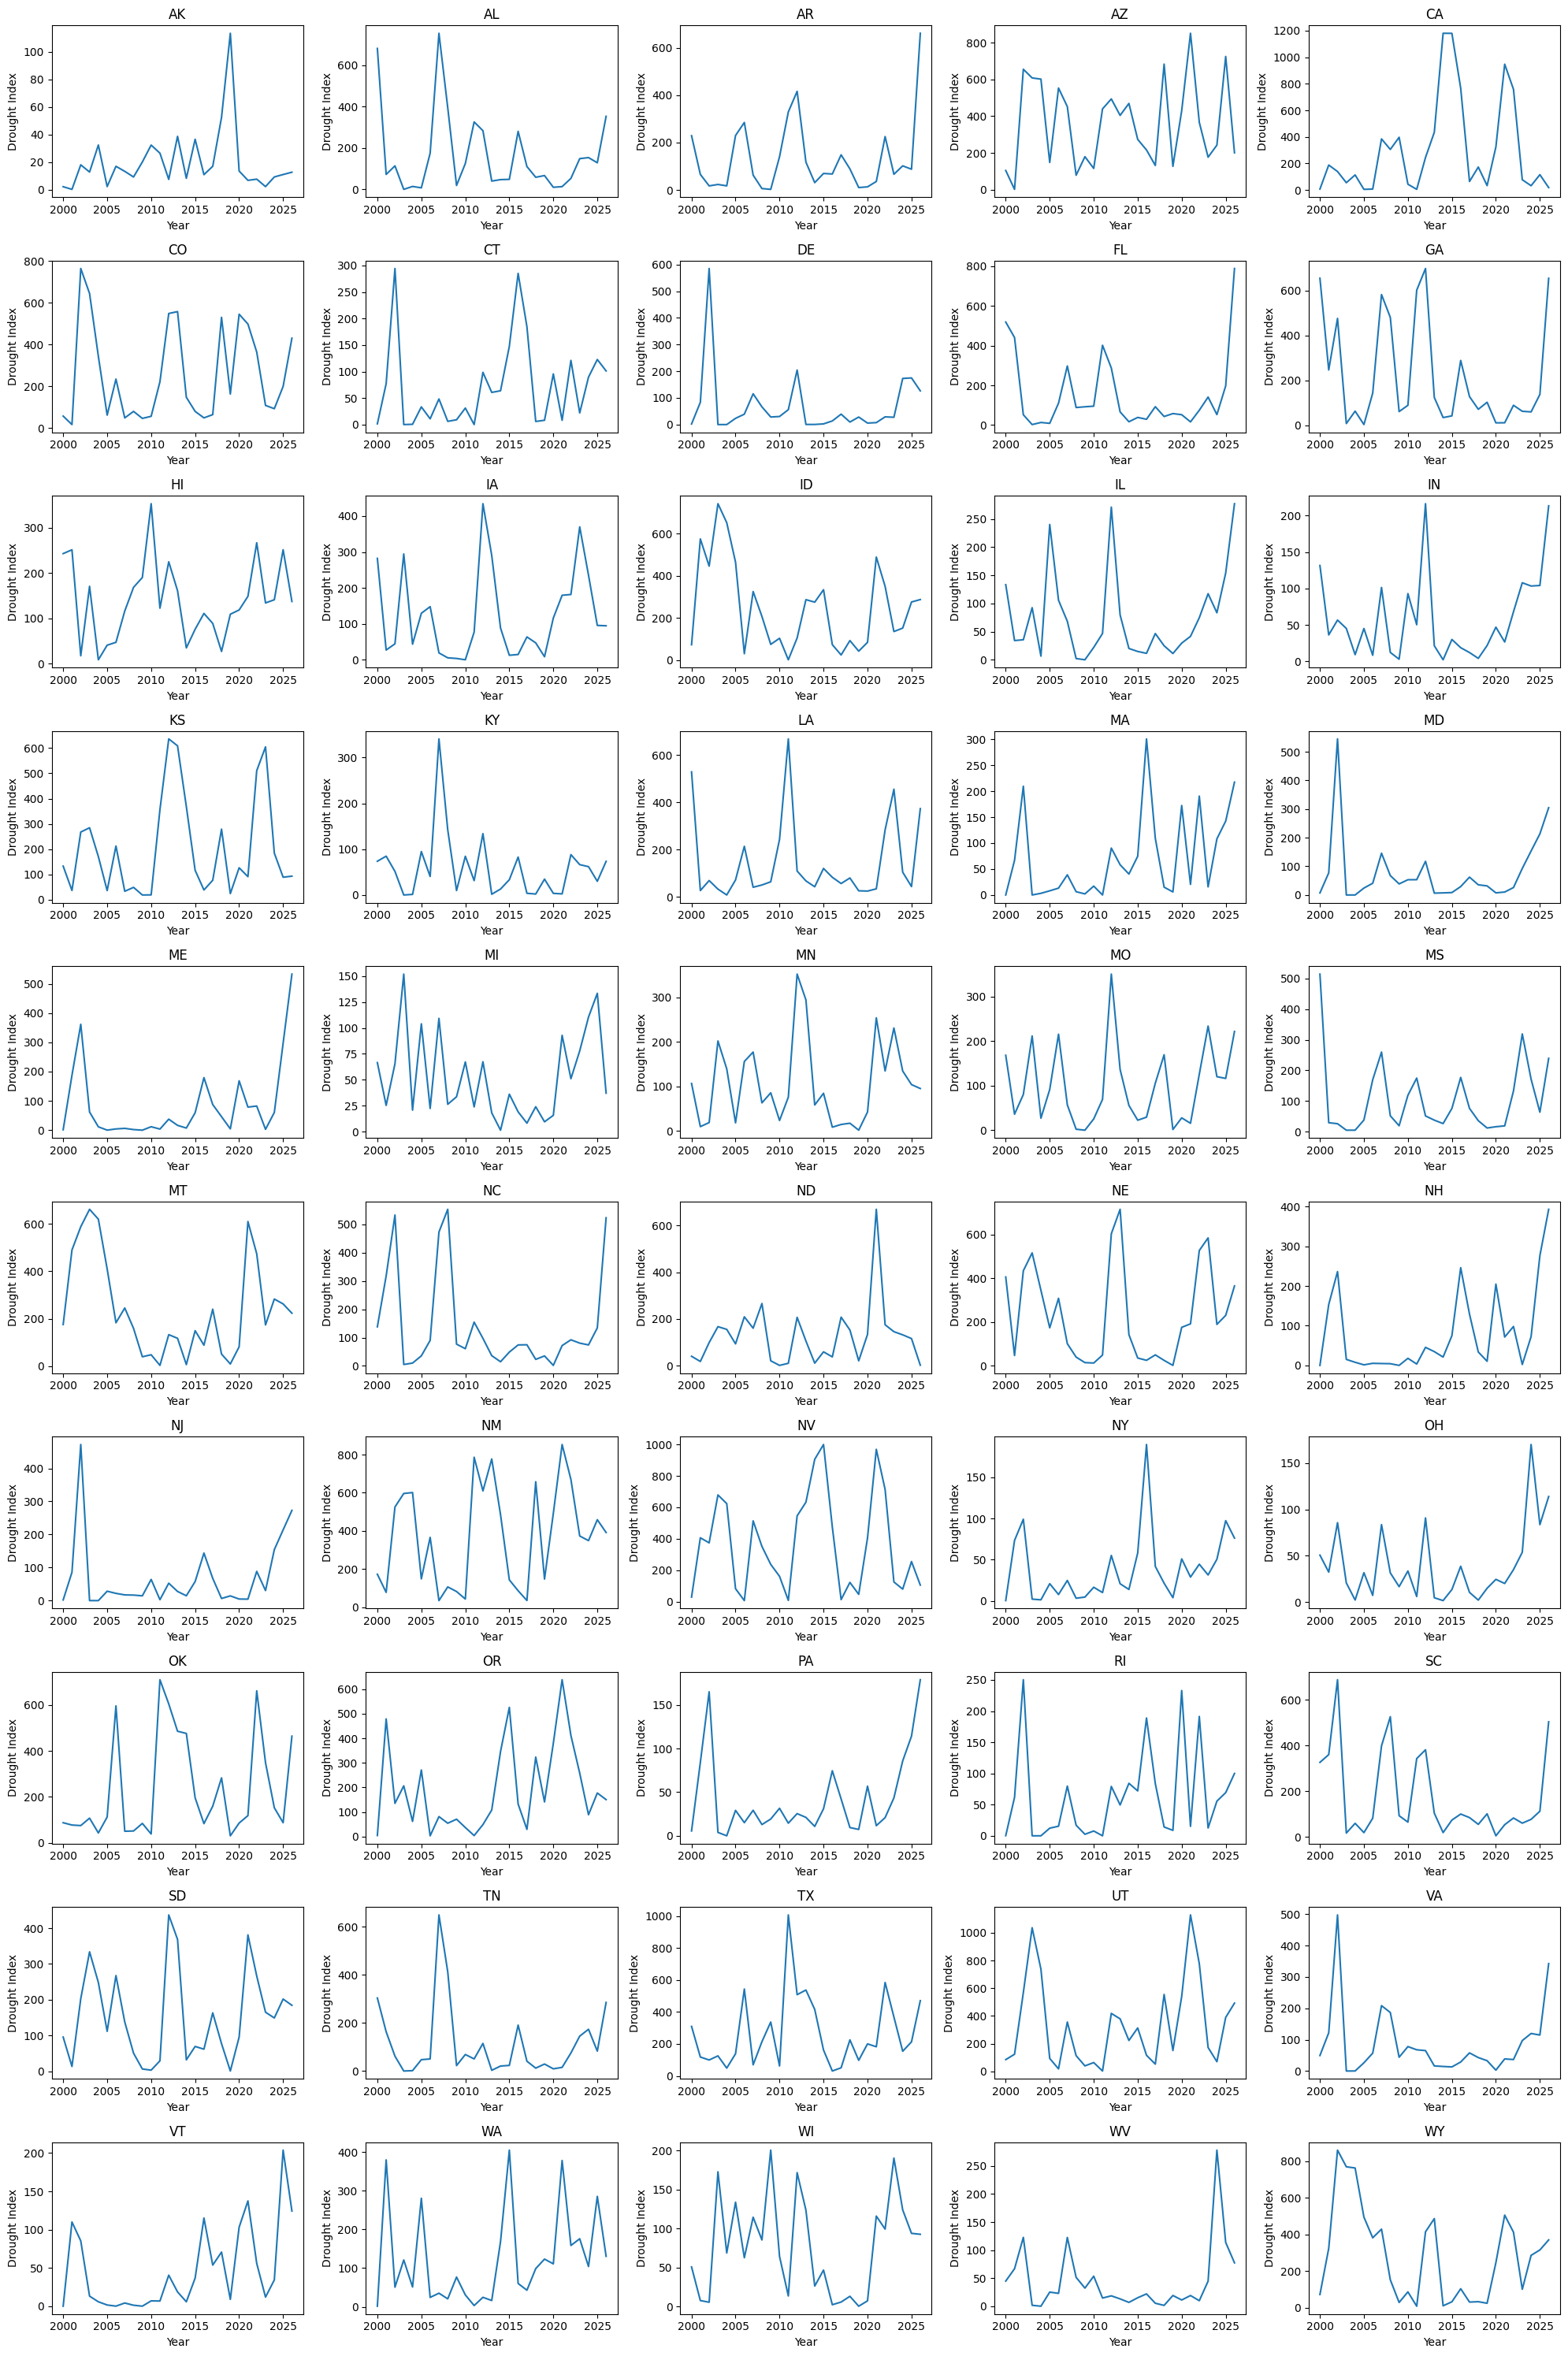

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 5, figsize=(20, 30))
axes = axes.flatten()

states = df_drought_index['State'].unique()

for i, state in enumerate(states):
    df_state = df_drought_index[df_drought_index['State'] == state]
    axes[i].plot(df_state['Year'], df_state['Drought Index'])
    axes[i].set_title(state)
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Drought Index')

plt.tight_layout()
plt.show()

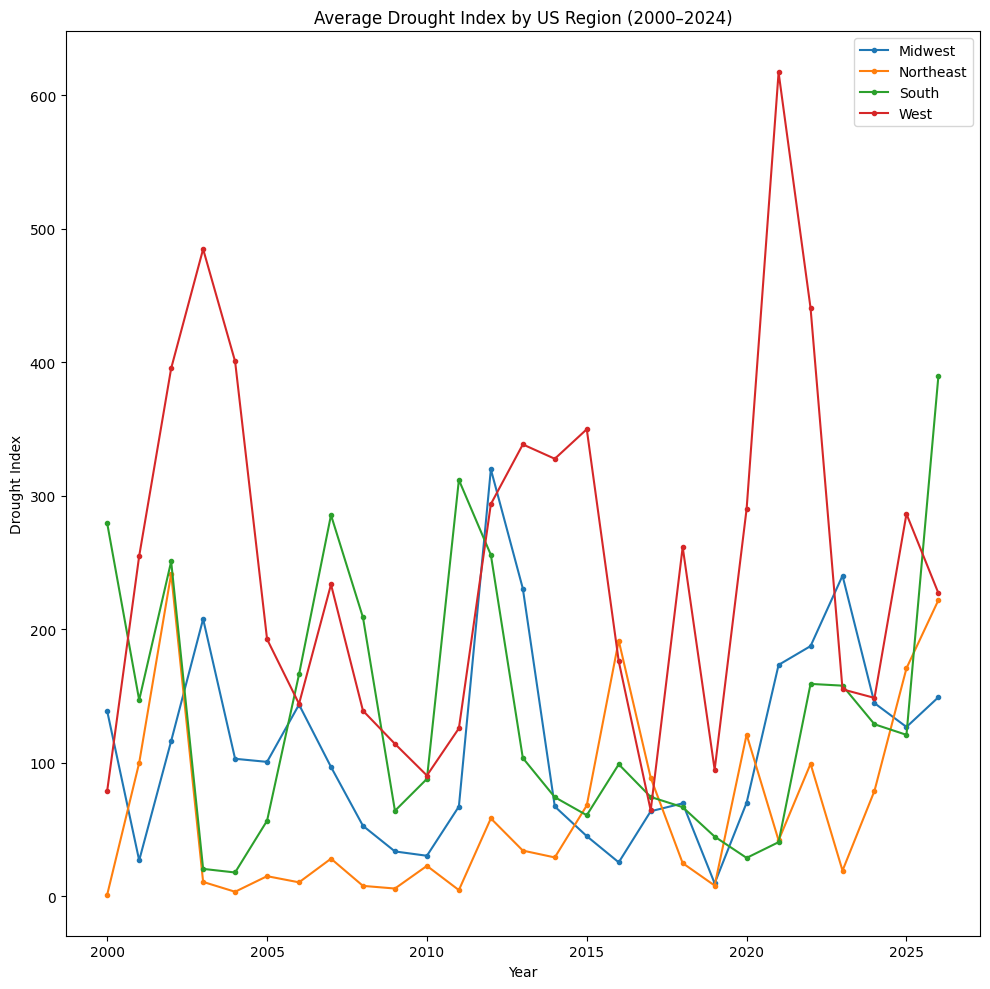

In [53]:

# Drought Index over time by US Census Region
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'WV': 'South', 'AL': 'South', 'KY': 'South',
    'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West',
}

df_drought_regional = df_drought_index.copy()
df_drought_regional['Region'] = df_drought_regional['State'].map(region_map)
df_drought_regional = df_drought_regional.dropna(subset=['Region'])
df_drought_regional = df_drought_regional.groupby(['Year', 'Region'])['Drought Index'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 10))
for region, group in df_drought_regional.groupby('Region'):
    ax.plot(group['Year'], group['Drought Index'], label=region, marker='o', markersize=3)

ax.set_title('Average Drought Index by US Region (2000–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Drought Index')
ax.legend()
plt.tight_layout()
plt.show()


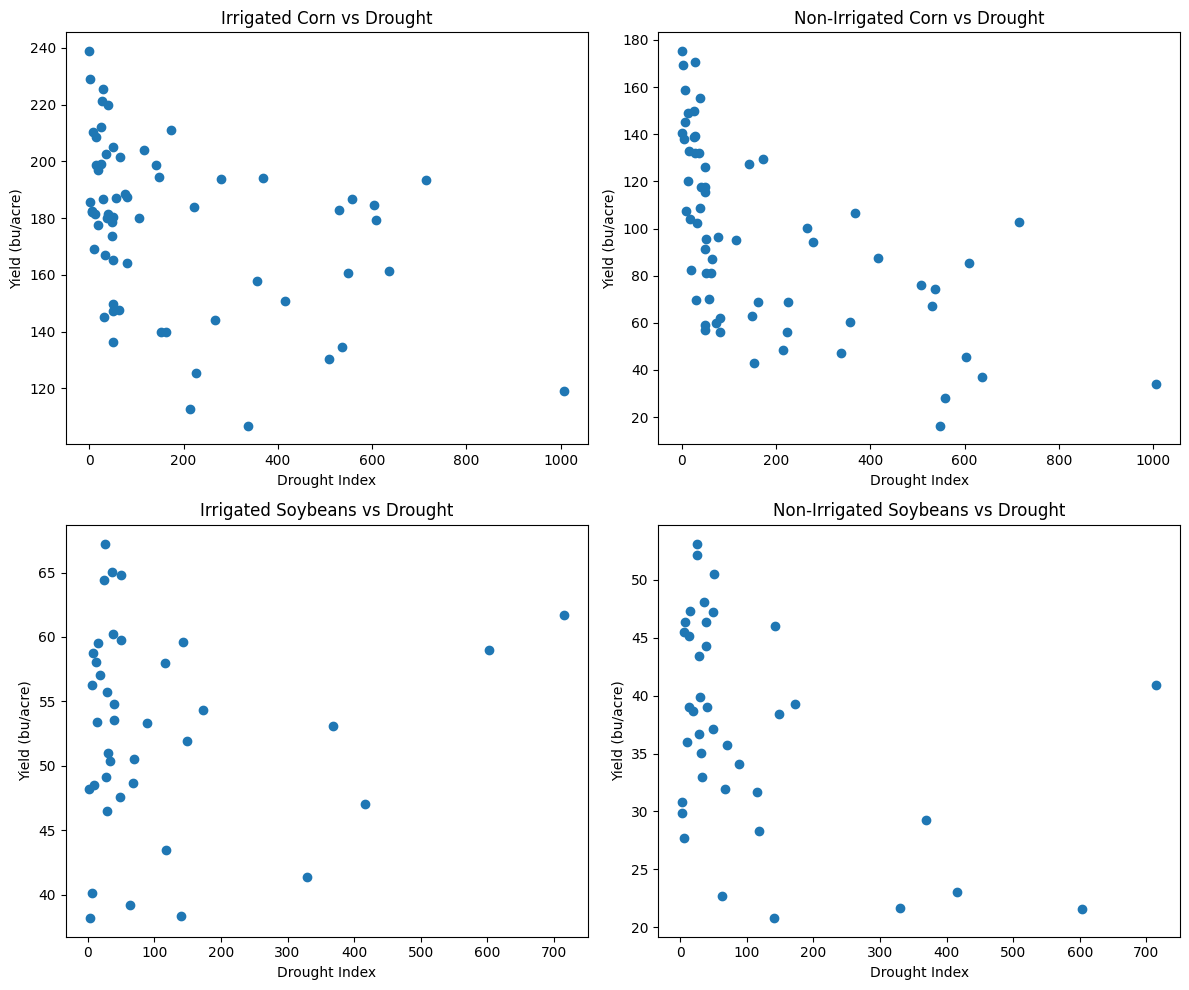

In [9]:
df_combined = df_crop_yields.merge(df_drought_index, on=['Year', 'State'])
#print(df_combined.head())

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].scatter(df_combined['Drought Index'], df_combined['Corn_Irrigated'])
axes[0,0].set_title('Irrigated Corn vs Drought')
axes[0,0].set_xlabel('Drought Index')
axes[0,0].set_ylabel('Yield (bu/acre)')

axes[0,1].scatter(df_combined['Drought Index'], df_combined['Corn_NonIrrigated'])
axes[0,1].set_title('Non-Irrigated Corn vs Drought')
axes[0,1].set_xlabel('Drought Index')
axes[0,1].set_ylabel('Yield (bu/acre)')

axes[1,0].scatter(df_combined['Drought Index'], df_combined['Soy_Irrigated'])
axes[1,0].set_title('Irrigated Soybeans vs Drought')
axes[1,0].set_xlabel('Drought Index')
axes[1,0].set_ylabel('Yield (bu/acre)')

axes[1,1].scatter(df_combined['Drought Index'], df_combined['Soy_NonIrrigated'])
axes[1,1].set_title('Non-Irrigated Soybeans vs Drought')
axes[1,1].set_xlabel('Drought Index')
axes[1,1].set_ylabel('Yield (bu/acre)')

plt.tight_layout()
plt.show()

      Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  Soy_NonIrrigated
Year                                                                    
2000             NaN          60.000000            NaN               NaN
2007      157.119048          79.626225      44.799451         27.819286
2008      155.310328          81.715323      47.097222         34.645532
2009      171.193045         107.441490      51.593208         38.636486
2010      173.438298          88.462842      48.214397         32.970131


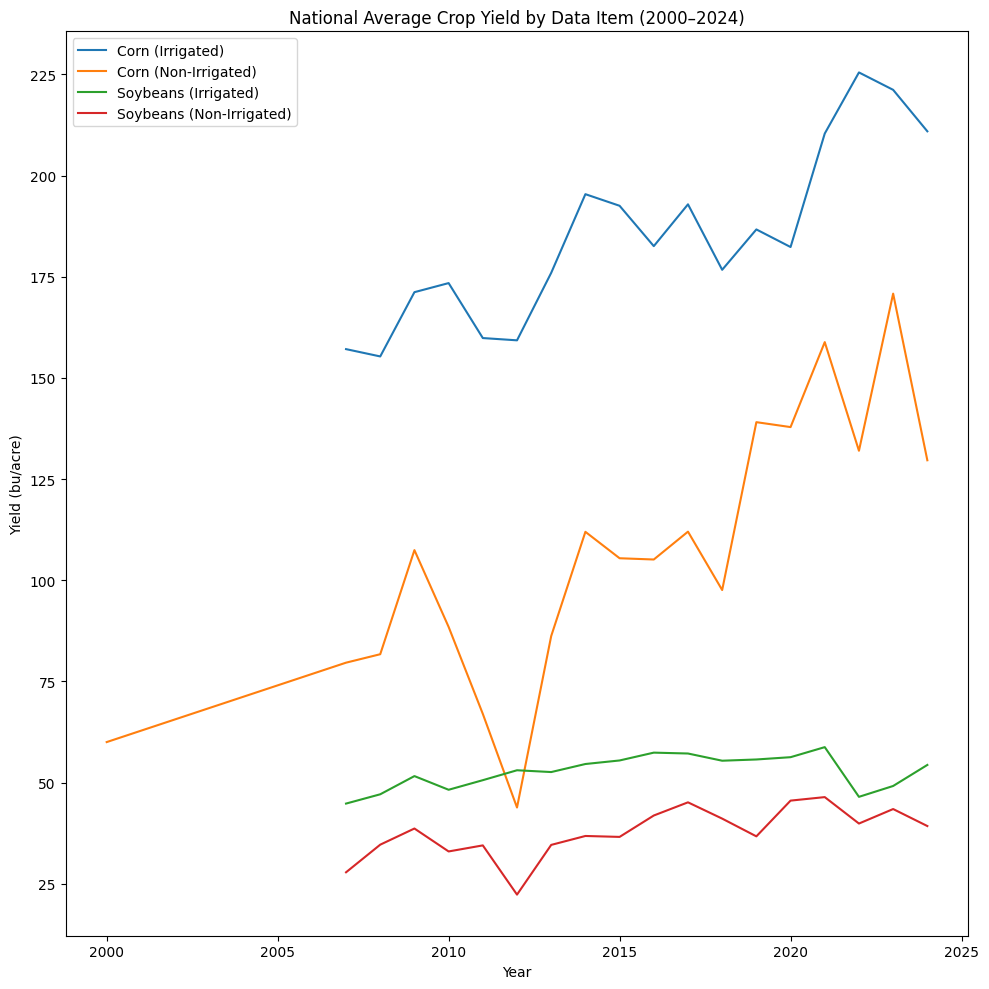

In [54]:
import matplotlib.pyplot as plt

# Average across all states per year
df_national = df_crop_yields.groupby('Year')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean()
print(df_national.head())
fig, ax = plt.subplots(figsize=(10, 10))

ax.plot(df_national.index, df_national['Corn_Irrigated'], label='Corn (Irrigated)')
ax.plot(df_national.index, df_national['Corn_NonIrrigated'], label='Corn (Non-Irrigated)')
ax.plot(df_national.index, df_national['Soy_Irrigated'], label='Soybeans (Irrigated)')
ax.plot(df_national.index, df_national['Soy_NonIrrigated'], label='Soybeans (Non-Irrigated)')

ax.set_title('National Average Crop Yield by Data Item (2000–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Yield (bu/acre)')
ax.legend()
plt.tight_layout()
plt.show()


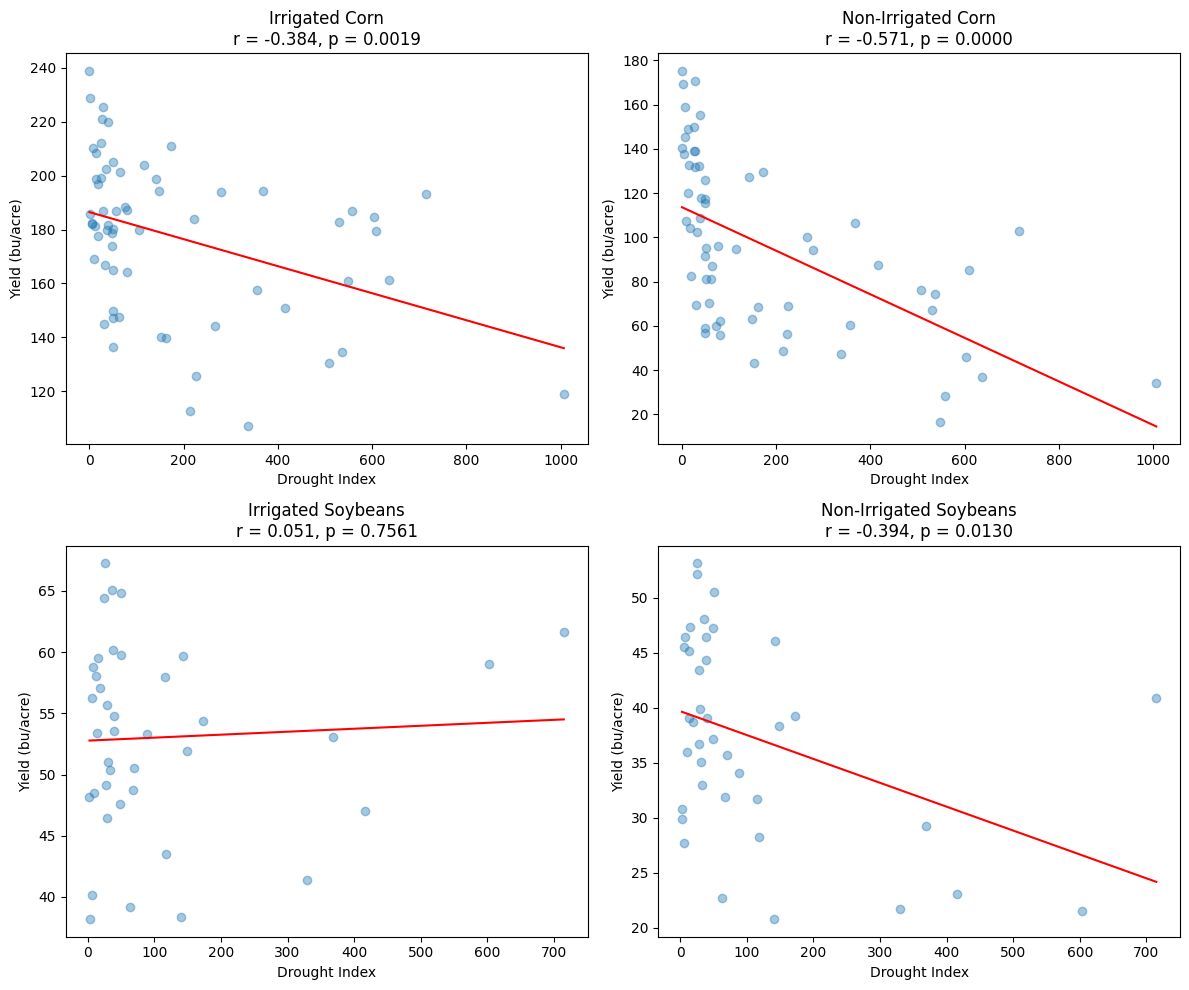

In [11]:
from scipy import stats
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
crop_labels = [
    ('Corn_Irrigated', 'Irrigated Corn'),
    ('Corn_NonIrrigated', 'Non-Irrigated Corn'),
    ('Soy_Irrigated', 'Irrigated Soybeans'),
    ('Soy_NonIrrigated', 'Non-Irrigated Soybeans'),
]

for ax, (col, label) in zip(axes.flatten(), crop_labels):
    subset = df_combined[['Drought Index', col]].dropna()
    x, y = subset['Drought Index'], subset[col]
    slope, intercept, r, p, _ = stats.linregress(x, y)
    
    ax.scatter(x, y, alpha=0.4)
    ax.plot(np.sort(x), slope * np.sort(x) + intercept, color='red')
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    ax.set_xlabel('Drought Index')
    ax.set_ylabel('Yield (bu/acre)')

plt.tight_layout()
plt.show()


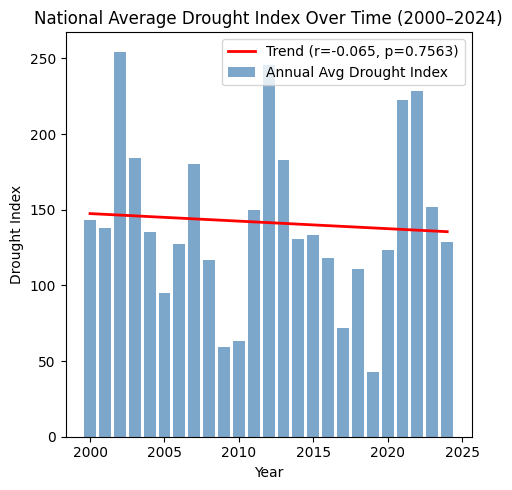

Trend slope: -0.50 index points/year
r = -0.065, p = 0.7563 — no significant trend


In [47]:
# Are droughts becoming more common over time?
df_trend = df_drought_index[df_drought_index['Year'] <= 2024]
df_trend = df_trend.groupby('Year')['Drought Index'].mean().reset_index()

slope, intercept, r, p, _ = stats.linregress(df_trend['Year'], df_trend['Drought Index'])

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(df_trend['Year'], df_trend['Drought Index'], color='steelblue', alpha=0.7, label='Annual Avg Drought Index')
ax.plot(df_trend['Year'], slope * df_trend['Year'] + intercept, color='red', linewidth=2, label=f'Trend (r={r:.3f}, p={p:.4f})')
ax.set_title('National Average Drought Index Over Time (2000–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Drought Index')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Trend slope: {slope:.2f} index points/year")
print(f"r = {r:.3f}, p = {p:.4f} — {'significant upward trend' if p < 0.05 and slope > 0 else 'no significant trend'}")


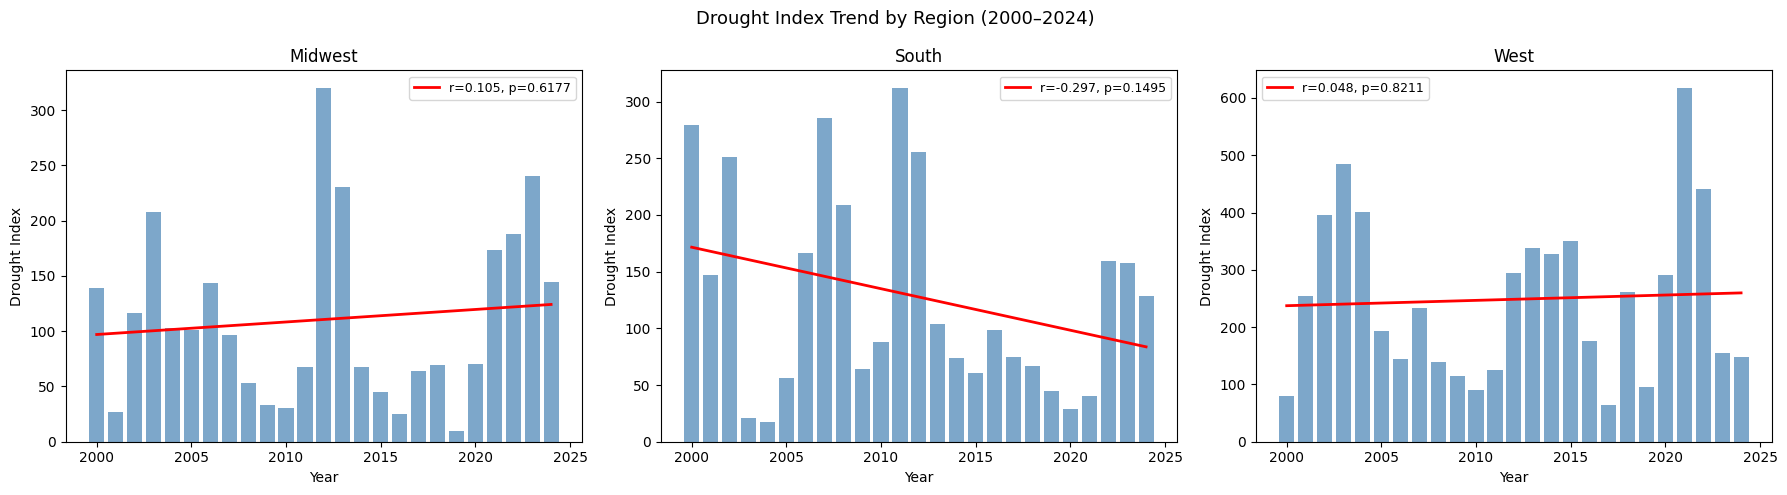

In [45]:
df_regional_drought = df_drought_index[df_drought_index['Year'] <= 2024].copy()
df_regional_drought['Region'] = df_regional_drought['State'].map(region_map)
df_regional_drought = df_regional_drought.dropna(subset=['Region'])
df_regional_drought = df_regional_drought.groupby(['Year', 'Region'])['Drought Index'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
regions = ['Midwest', 'South', 'West']

for ax, region in zip(axes, regions):
    df_r = df_regional_drought[df_regional_drought['Region'] == region]
    slope, intercept, r, p, _ = stats.linregress(df_r['Year'], df_r['Drought Index'])
    ax.bar(df_r['Year'], df_r['Drought Index'], color='steelblue', alpha=0.7)
    ax.plot(df_r['Year'], slope * df_r['Year'] + intercept, color='red', linewidth=2,
            label=f'r={r:.3f}, p={p:.4f}')
    ax.set_title(region)
    ax.set_xlabel('Year')
    ax.set_ylabel('Drought Index')
    ax.legend(fontsize=9)

plt.suptitle('Drought Index Trend by Region (2000–2024)', fontsize=13)
plt.tight_layout()
plt.show()


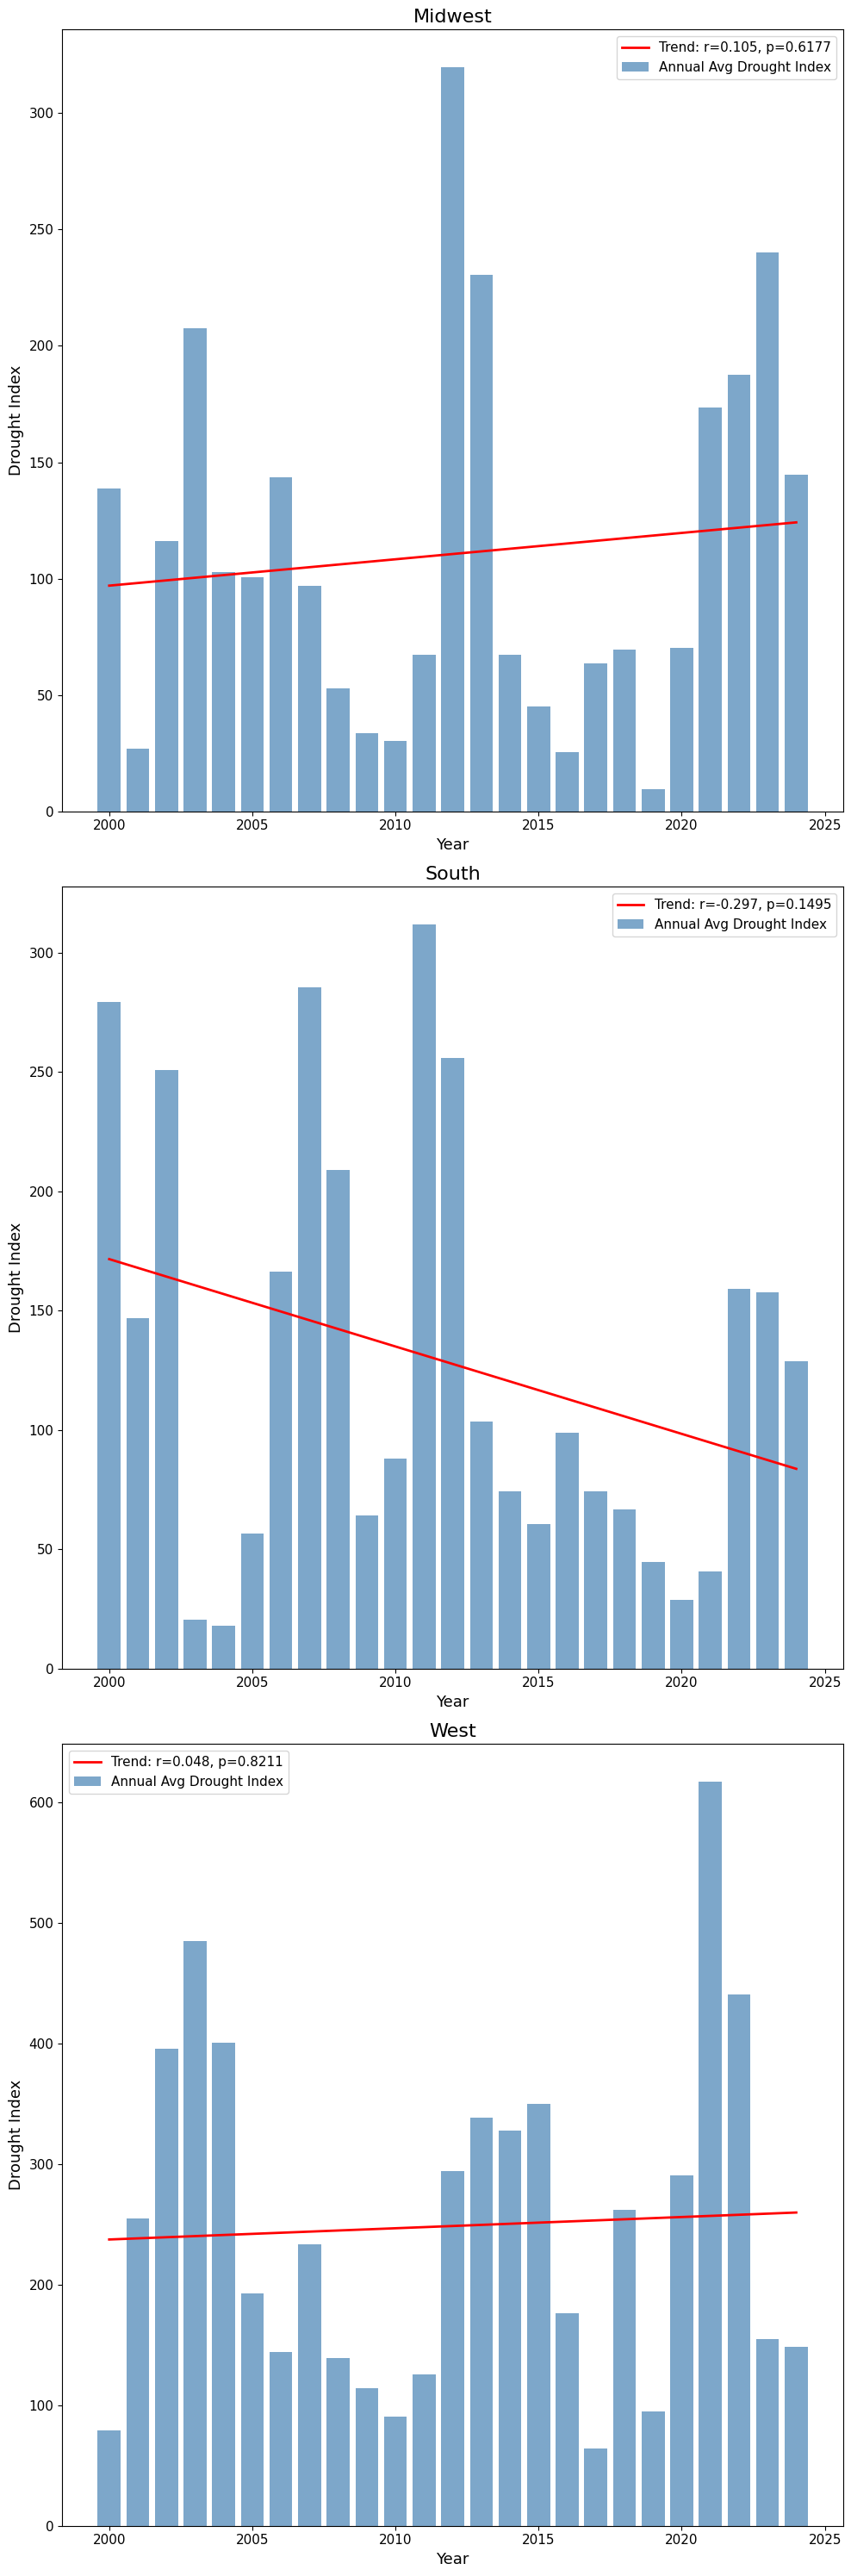

In [52]:
fig, axes = plt.subplots(3, 1, figsize=(10, 30))
regions = ['Midwest', 'South', 'West']

for ax, region in zip(axes, regions):
    df_r = df_regional_drought[df_regional_drought['Region'] == region]
    slope, intercept, r, p, _ = stats.linregress(df_r['Year'], df_r['Drought Index'])
    ax.bar(df_r['Year'], df_r['Drought Index'], color='steelblue', alpha=0.7, label='Annual Avg Drought Index')
    ax.plot(df_r['Year'], slope * df_r['Year'] + intercept, color='red', linewidth=2,
            label=f'Trend: r={r:.3f}, p={p:.4f}')
    ax.set_title(region, fontsize=16)
    ax.set_xlabel('Year', fontsize=13)
    ax.set_ylabel('Drought Index', fontsize=13)
    ax.tick_params(labelsize=11)
    ax.legend(fontsize=11)

#plt.suptitle('Drought Index Trend by Region (2000–2024)', fontsize=18)
plt.tight_layout()
plt.show()


Pearson r by Region (negative = drought hurts yield):
Crop     Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  Soy_NonIrrigated
Region                                                                     
Midwest          -0.229             -0.671          0.005            -0.540
South            -0.592             -0.657         -0.214            -0.526
West              0.001             -0.634            NaN               NaN


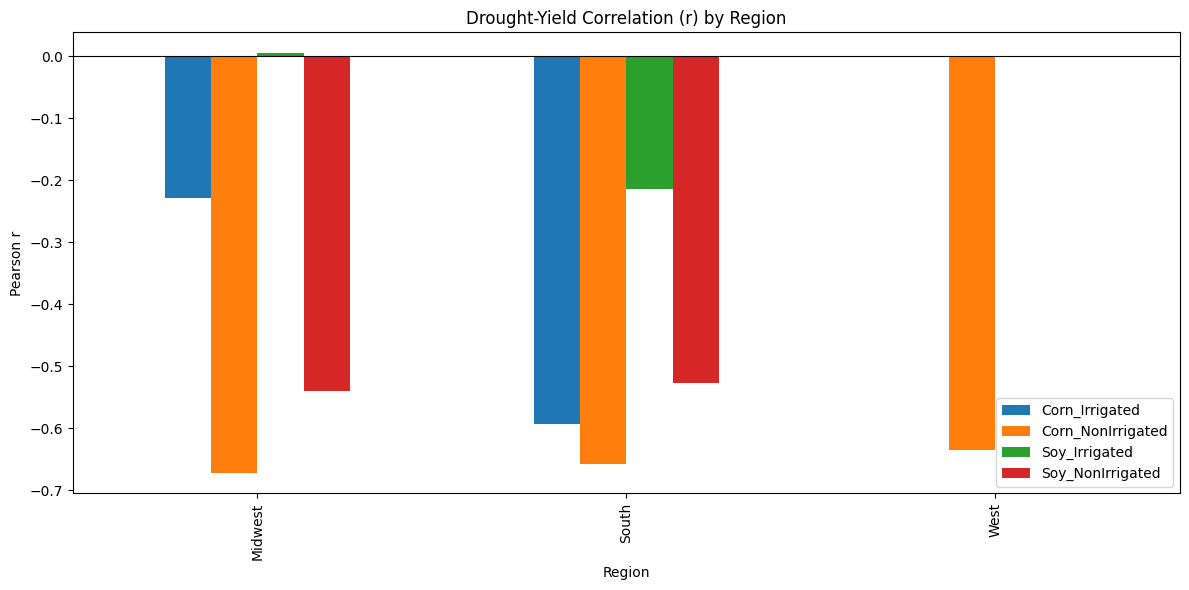

In [13]:
# Does the region matter? Drought-yield correlation by US Census Region
crops = ['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']

df_combined_region = df_combined.copy()
df_combined_region['Region'] = df_combined_region['State'].map(region_map)
df_combined_region = df_combined_region.dropna(subset=['Region'])

results = []
for region in df_combined_region['Region'].unique():
    df_r = df_combined_region[df_combined_region['Region'] == region]
    for crop in crops:
        subset = df_r[['Drought Index', crop]].dropna()
        if len(subset) < 5:
            continue
        r, p = stats.pearsonr(subset['Drought Index'], subset[crop])
        results.append({'Region': region, 'Crop': crop, 'r': r, 'p': p, 'n': len(subset)})

df_regions_correlations = pd.DataFrame(results).pivot(index='Region', columns='Crop', values='r').round(3)
print("Pearson r by Region (negative = drought hurts yield):")
print(df_regions_correlations.to_string())

df_regions_correlations.plot(kind='bar', figsize=(12, 6))
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Drought-Yield Correlation (r) by Region')
plt.ylabel('Pearson r')
plt.xlabel('Region')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


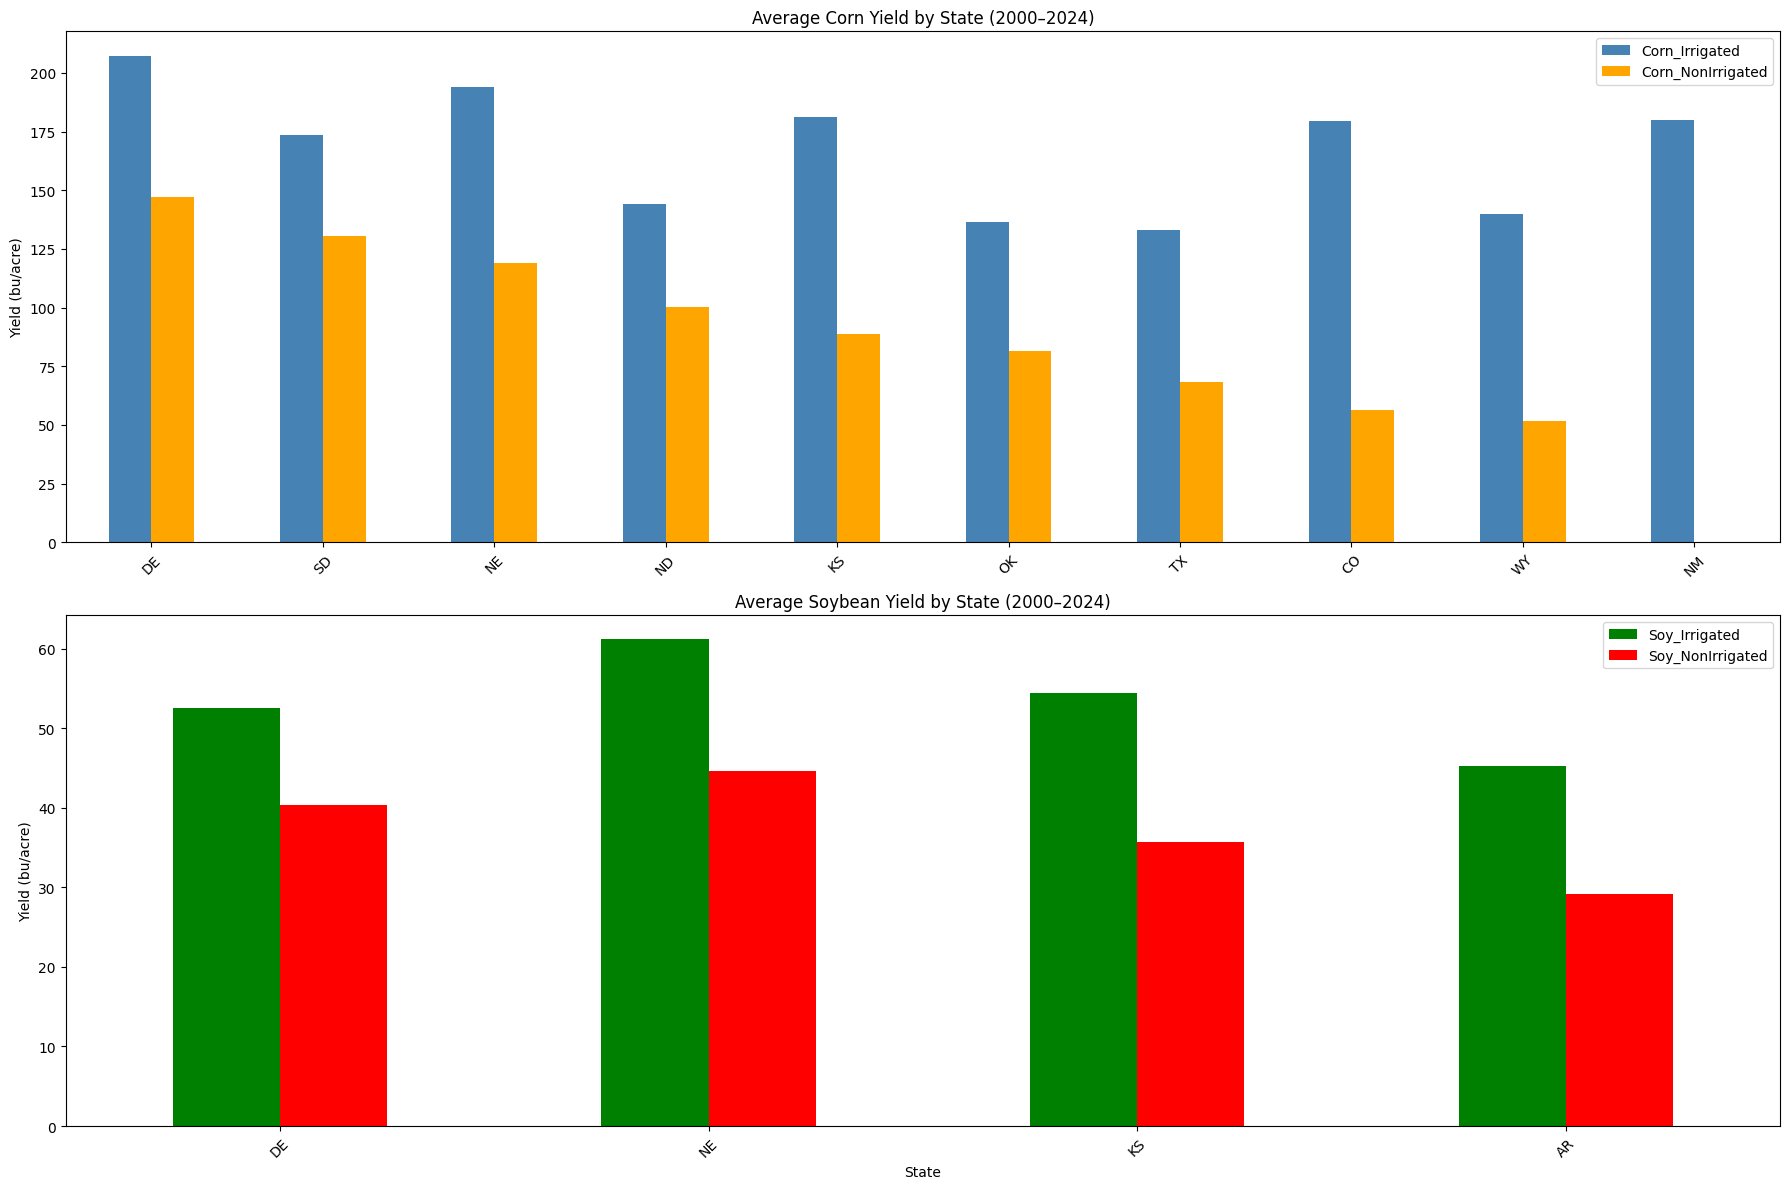

In [14]:
# Crop yield per state - split into two charts for readability
df_state_yield = df_crop_yields.groupby('State')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean().dropna(how='all')
df_state_yield = df_state_yield.sort_values('Corn_NonIrrigated', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Corn
df_state_yield[['Corn_Irrigated', 'Corn_NonIrrigated']].dropna(how='all').plot(
    kind='bar', ax=axes[0], color=['steelblue', 'orange']
)
axes[0].set_title('Average Corn Yield by State (2000–2024)')
axes[0].set_ylabel('Yield (bu/acre)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Soybeans
df_state_yield[['Soy_Irrigated', 'Soy_NonIrrigated']].dropna(how='all').plot(
    kind='bar', ax=axes[1], color=['green', 'red']
)
axes[1].set_title('Average Soybean Yield by State (2000–2024)')
axes[1].set_ylabel('Yield (bu/acre)')
axes[1].set_xlabel('State')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


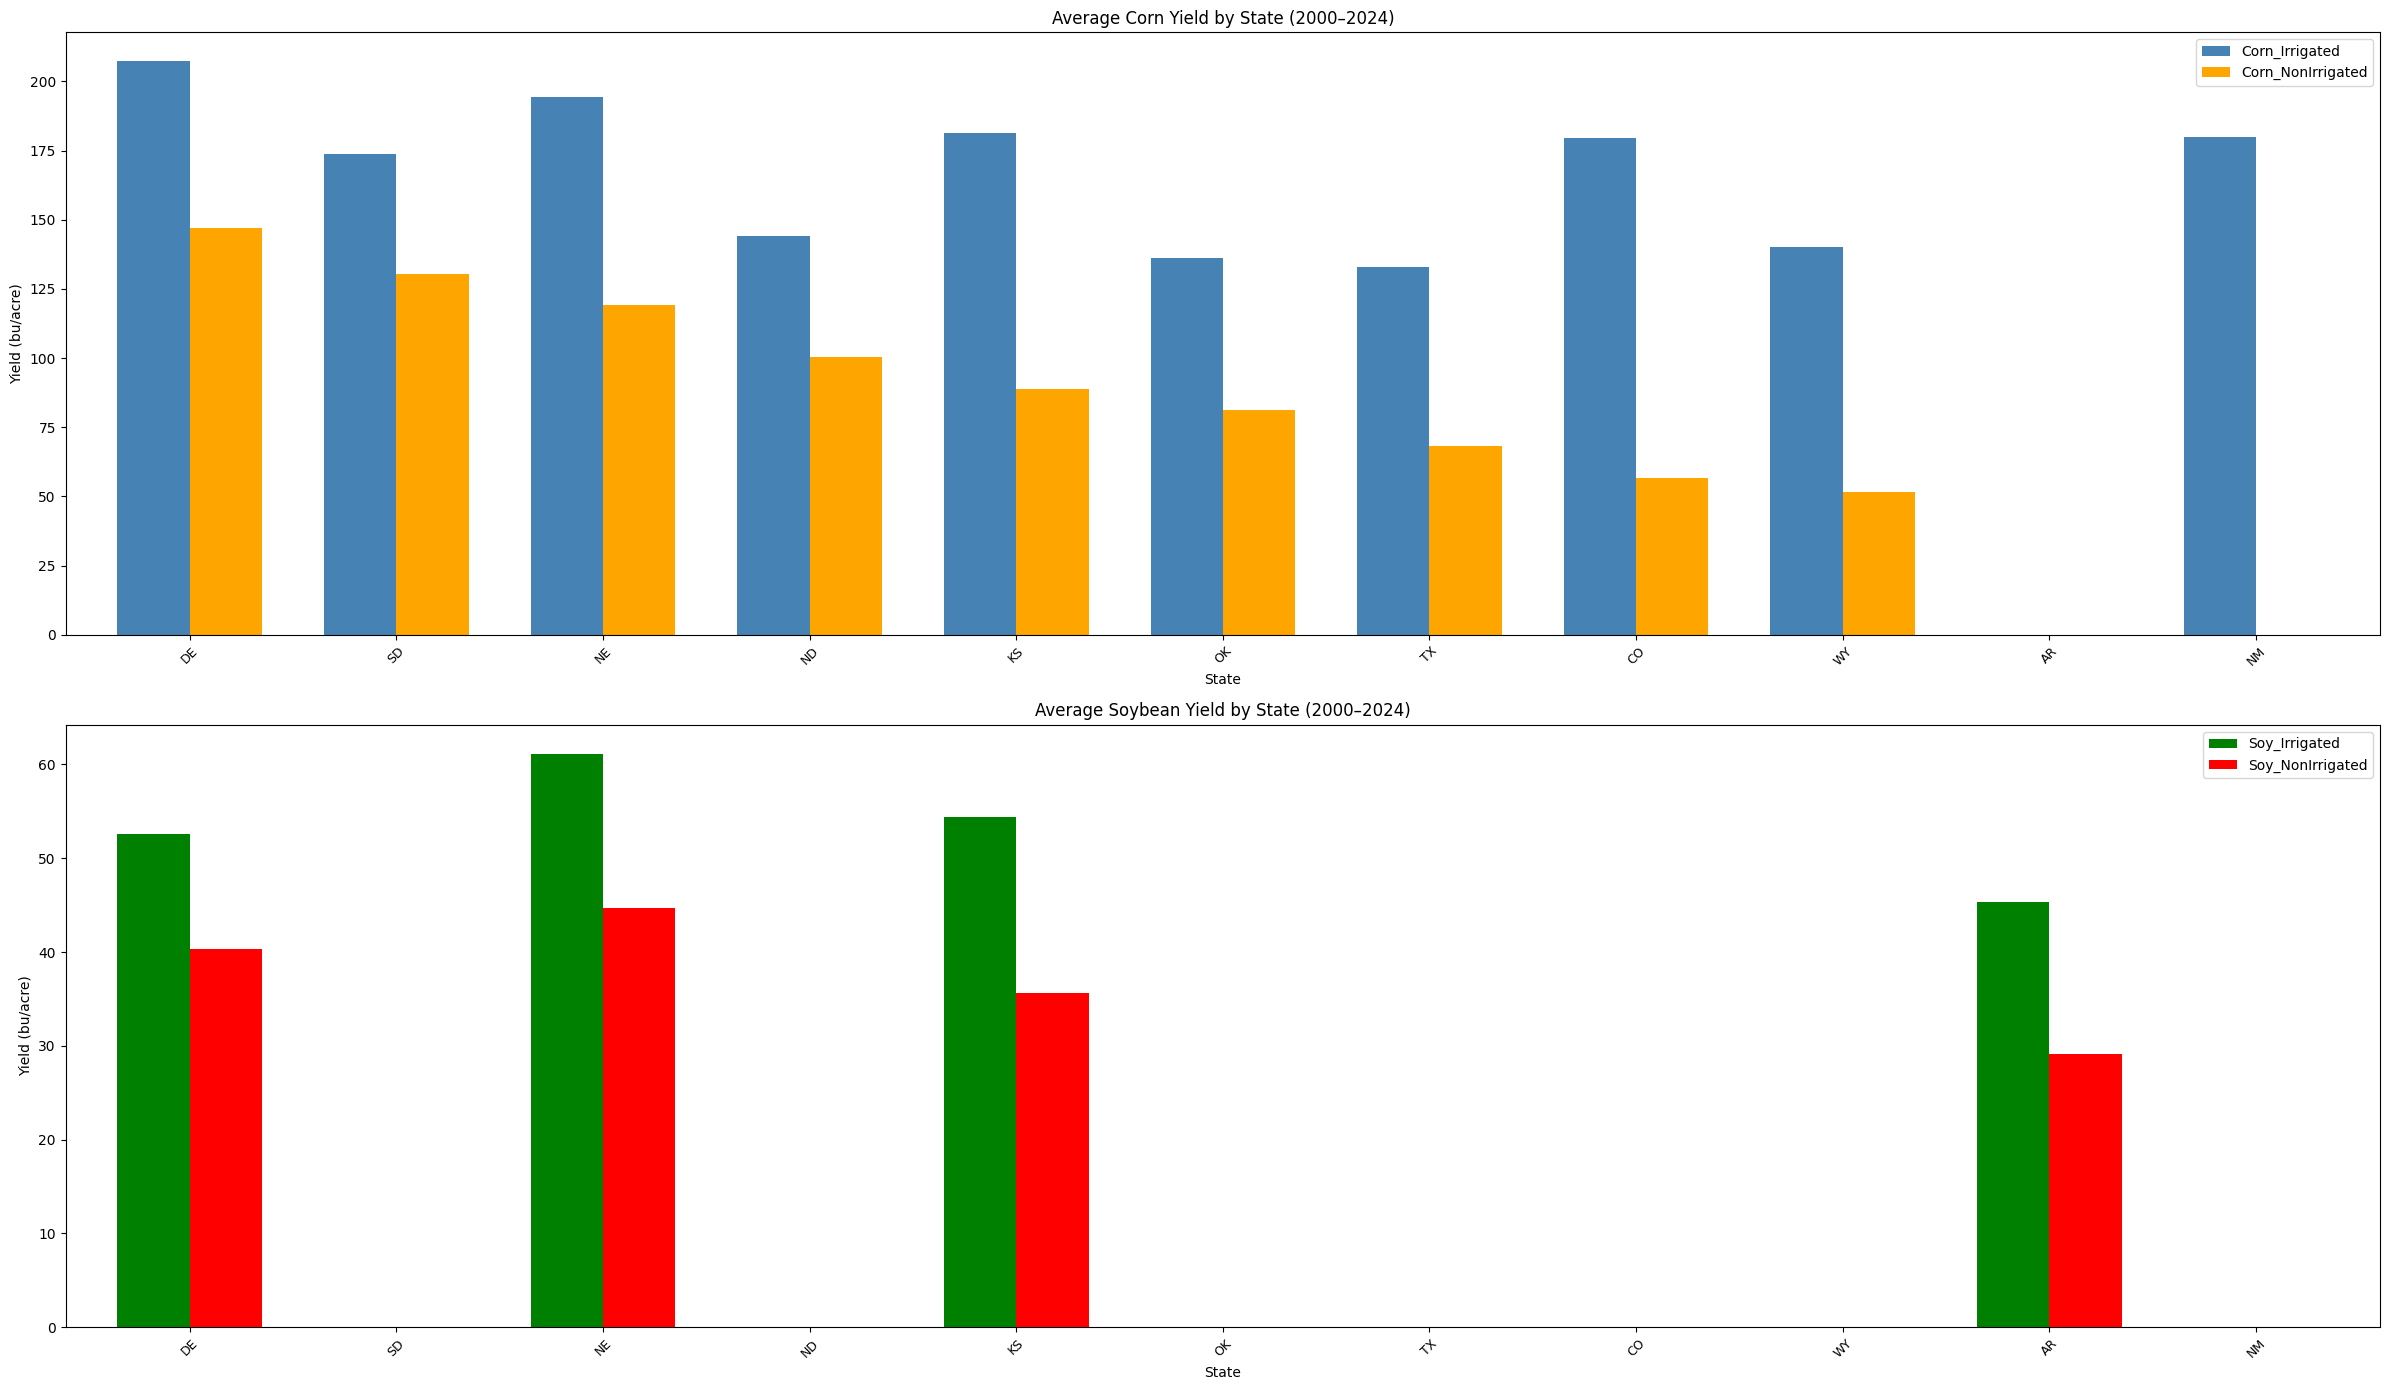

In [15]:
# All states - corn and soybeans split into two charts
df_state_yield = df_crop_yields.groupby('State')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean()
df_state_yield = df_state_yield.sort_values('Corn_NonIrrigated', ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(24, 14))

df_state_yield[['Corn_Irrigated', 'Corn_NonIrrigated']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'orange'], width=0.7
)
axes[0].set_title('Average Corn Yield by State (2000–2024)')
axes[0].set_ylabel('Yield (bu/acre)')
axes[0].tick_params(axis='x', rotation=45, labelsize=9)

df_state_yield[['Soy_Irrigated', 'Soy_NonIrrigated']].plot(
    kind='bar', ax=axes[1], color=['green', 'red'], width=0.7
)
axes[1].set_title('Average Soybean Yield by State (2000–2024)')
axes[1].set_ylabel('Yield (bu/acre)')
axes[1].set_xlabel('State')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)

plt.tight_layout()
plt.show()


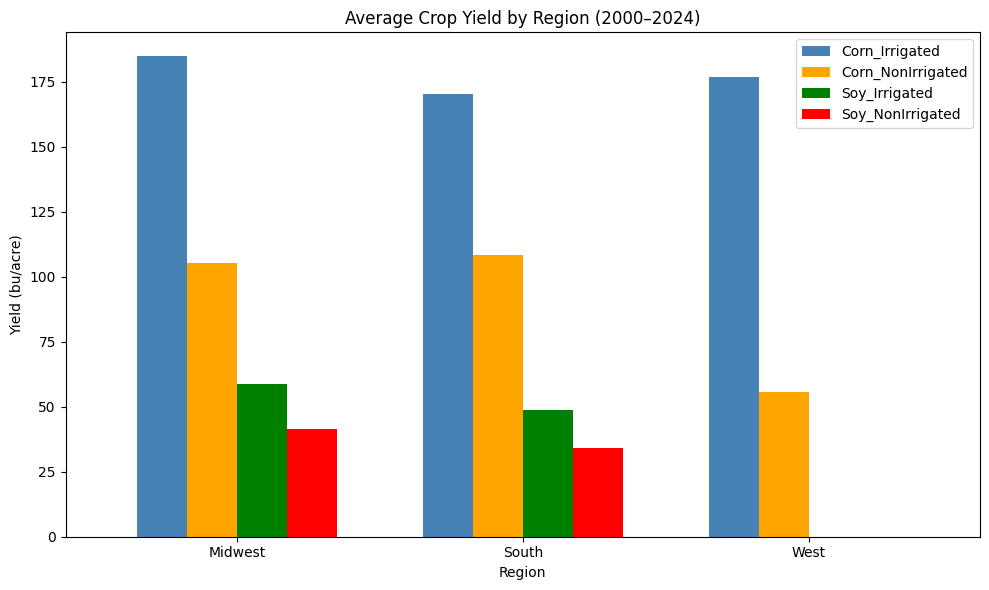

         Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  Soy_NonIrrigated
Region                                                                     
Midwest           184.7              105.2           58.8              41.5
South             170.3              108.3           48.6              34.2
West              176.7               55.8            NaN               NaN


In [16]:
# Agricultural output per region
df_state_yield_region = df_crop_yields.copy()
df_state_yield_region['Region'] = df_state_yield_region['State'].map(region_map)
df_state_yield_region = df_state_yield_region.dropna(subset=['Region'])

df_region_yield = df_state_yield_region.groupby('Region')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean()

df_region_yield.plot(kind='bar', figsize=(10, 6), color=['steelblue', 'orange', 'green', 'red'], width=0.7)
plt.title('Average Crop Yield by Region (2000–2024)')
plt.ylabel('Yield (bu/acre)')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(df_region_yield.round(1).to_string())


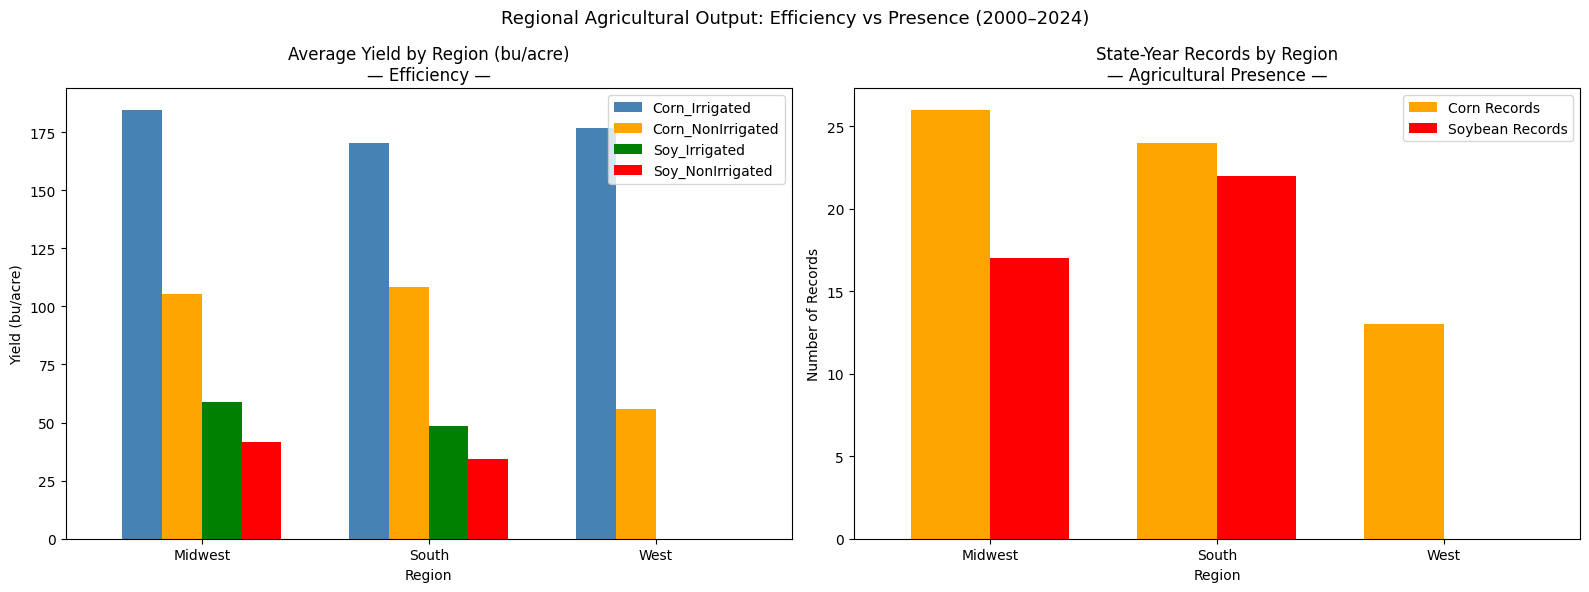


Average Yield (bu/acre):
         Corn_Irrigated  Corn_NonIrrigated  Soy_Irrigated  Soy_NonIrrigated
Region                                                                     
Midwest           184.7              105.2           58.8              41.5
South             170.3              108.3           48.6              34.2
West              176.7               55.8            NaN               NaN

Record Count (proxy for agricultural presence):
         Corn Records  Soybean Records
Region                                
Midwest            26               17
South              24               22
West               13                0


In [17]:
# Agricultural presence and yield efficiency by region
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: average yield (efficiency)
df_region_yield_mean = df_state_yield_region.groupby('Region')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean()
df_region_yield_mean.plot(kind='bar', ax=axes[0], color=['steelblue', 'orange', 'green', 'red'], width=0.7)
axes[0].set_title('Average Yield by Region (bu/acre)\n— Efficiency —')
axes[0].set_ylabel('Yield (bu/acre)')
axes[0].set_xlabel('Region')
axes[0].tick_params(axis='x', rotation=0)

# Right: count of state-year records (agricultural presence)
df_region_count = df_state_yield_region.groupby('Region')[['Corn_NonIrrigated', 'Soy_NonIrrigated']].count()
df_region_count.columns = ['Corn Records', 'Soybean Records']
df_region_count.plot(kind='bar', ax=axes[1], color=['orange', 'red'], width=0.7)
axes[1].set_title('State-Year Records by Region\n— Agricultural Presence —')
axes[1].set_ylabel('Number of Records')
axes[1].set_xlabel('Region')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Regional Agricultural Output: Efficiency vs Presence (2000–2024)', fontsize=13)
plt.tight_layout()
plt.show()

print("\nAverage Yield (bu/acre):")
print(df_region_yield_mean.round(1).to_string())
print("\nRecord Count (proxy for agricultural presence):")
print(df_region_count.to_string())


Unique counties reporting non-irrigated yield data by region:
         Unique Counties
Region                  
Midwest              192
South                 96
West                  17


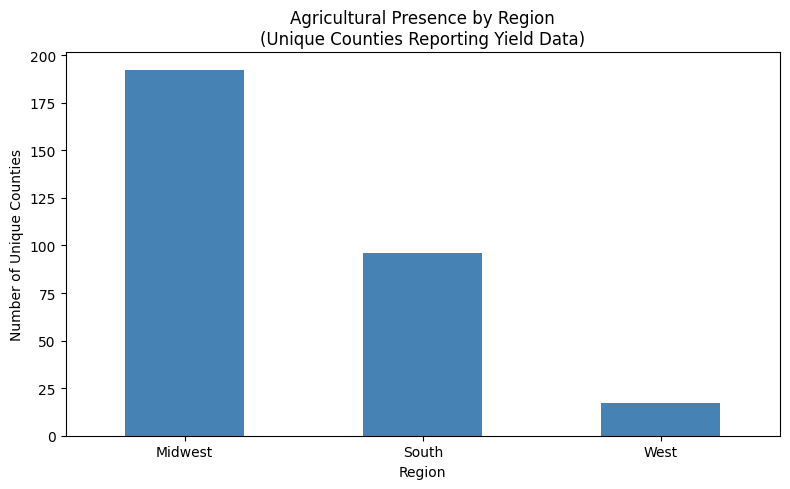

In [29]:
# Count unique counties per region as proxy for agricultural presence
df_county_region = df_crops[['State', 'County', 'Data Item']].copy()
df_county_region = df_county_region[df_county_region['County'] != 'OTHER COUNTIES']
df_county_region['State'] = df_county_region['State'].map(state_abbrev)
df_county_region['Region'] = df_county_region['State'].map(region_map)
df_county_region = df_county_region.dropna(subset=['Region'])

df_county_count = df_county_region[df_county_region['Data Item'].str.contains('NON-IRRIGATED - YIELD')]
df_county_count = df_county_count.groupby('Region')[['County']].nunique().rename(columns={'County': 'Unique Counties'})

print("Unique counties reporting non-irrigated yield data by region:")
print(df_county_count)

df_county_count.plot(kind='bar', figsize=(8, 5), legend=False, color='steelblue')
plt.title('Agricultural Presence by Region\n(Unique Counties Reporting Yield Data)')
plt.ylabel('Number of Unique Counties')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


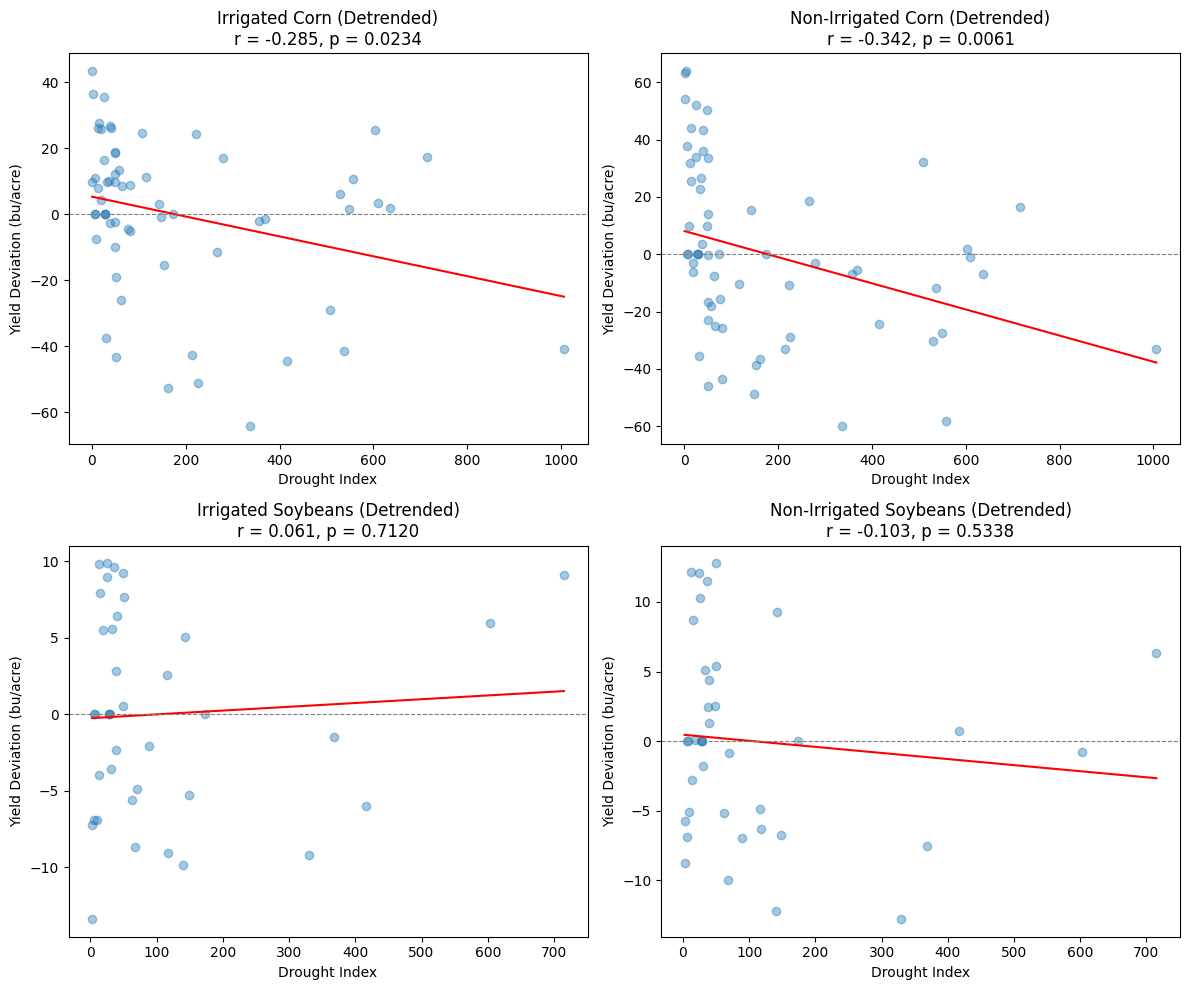

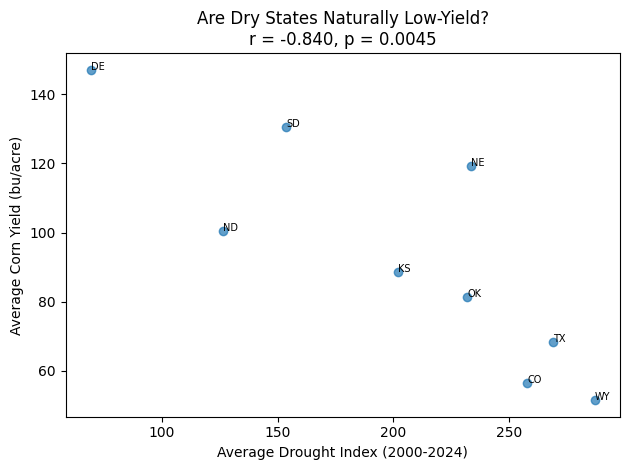

States with non-irrigated corn yield data:
['AR', 'CO', 'DE', 'KS', 'ND', 'NE', 'NM', 'OK', 'SD', 'TX', 'WY']
Total: 11


In [32]:
# Detrend yields by subtracting the national average for each year
# This removes the technology improvement trend, isolating drought's effect

df_national_avg = df_crop_yields.groupby('Year')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean()

df_detrended = df_crop_yields.copy()
df_detrended = df_detrended.merge(df_national_avg, on='Year', suffixes=('', '_national'))

for crop in ['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']:
    df_detrended[crop] = df_detrended[crop] - df_detrended[f'{crop}_national']

df_detrended = df_detrended[['Year', 'State', 'Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']]

# Re-run correlation on detrended yields
df_merged_detrended = df_detrended.merge(df_drought_index, on=['Year', 'State'])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
crop_labels = [
    ('Corn_Irrigated', 'Irrigated Corn (Detrended)'),
    ('Corn_NonIrrigated', 'Non-Irrigated Corn (Detrended)'),
    ('Soy_Irrigated', 'Irrigated Soybeans (Detrended)'),
    ('Soy_NonIrrigated', 'Non-Irrigated Soybeans (Detrended)'),
]

for ax, (col, label) in zip(axes.flatten(), crop_labels):
    subset = df_merged_detrended[['Drought Index', col]].dropna()
    x, y = subset['Drought Index'], subset[col]
    slope, intercept, r, p, _ = stats.linregress(x, y)

    ax.scatter(x, y, alpha=0.4)
    ax.plot(np.sort(x), slope * np.sort(x) + intercept, color='red')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    ax.set_xlabel('Drought Index')
    ax.set_ylabel('Yield Deviation (bu/acre)')

plt.tight_layout()
plt.show()

# Check if high-drought states are naturally low-yield states
df_state_avg_drought = df_drought_index.groupby('State')['Drought Index'].mean()
df_state_avg_yield = df_crop_yields.groupby('State')['Corn_NonIrrigated'].mean()

df_state_check = pd.DataFrame({'Avg Drought': df_state_avg_drought, 'Avg Yield': df_state_avg_yield}).dropna()
r, p = stats.pearsonr(df_state_check['Avg Drought'], df_state_check['Avg Yield'])

plt.scatter(df_state_check['Avg Drought'], df_state_check['Avg Yield'], alpha=0.7)
for state, row in df_state_check.iterrows():
    plt.annotate(state, (row['Avg Drought'], row['Avg Yield']), fontsize=7)
plt.xlabel('Average Drought Index (2000-2024)')
plt.ylabel('Average Corn Yield (bu/acre)')
plt.title(f'Are Dry States Naturally Low-Yield?\nr = {r:.3f}, p = {p:.4f}')
plt.tight_layout()
plt.show()

print("States with non-irrigated corn yield data:")
print(sorted(df_crop_yields['State'].dropna().unique()))
print(f"Total: {df_crop_yields['State'].dropna().nunique()}")


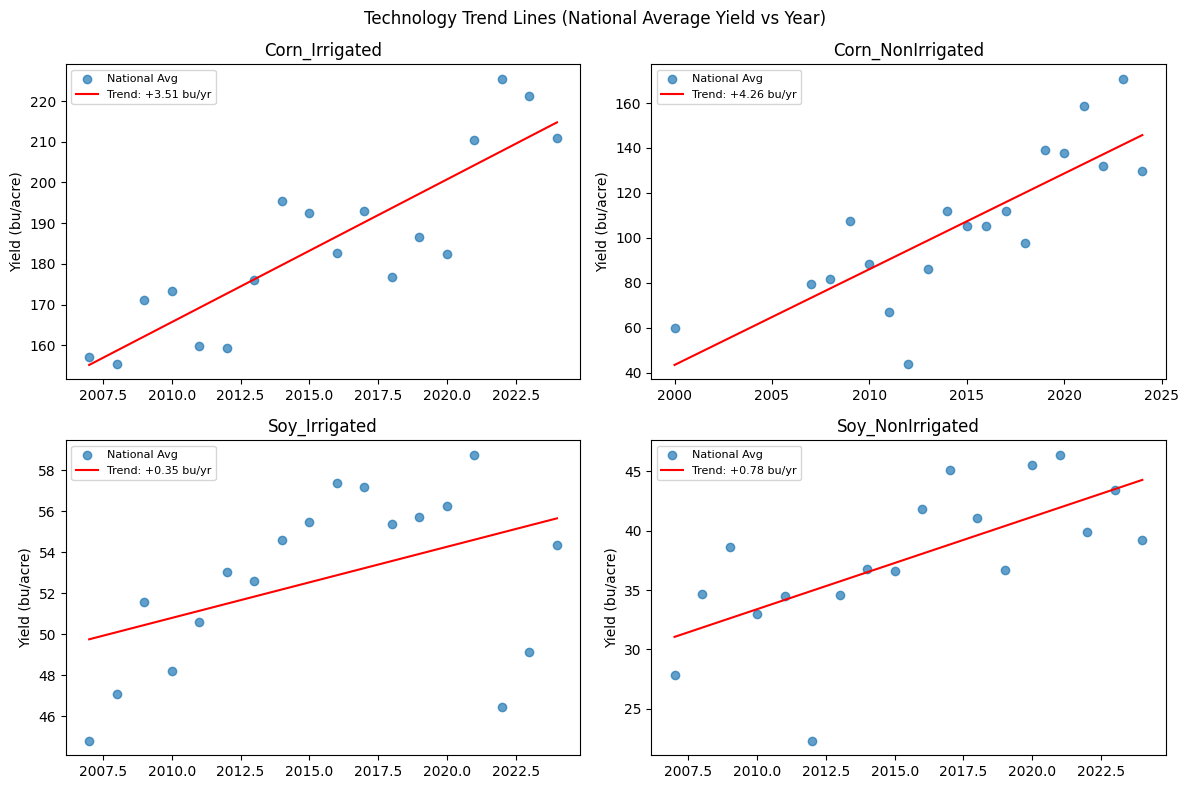

Corn_Irrigated: +3.51 bu/acre per year
Corn_NonIrrigated: +4.26 bu/acre per year
Soy_Irrigated: +0.35 bu/acre per year
Soy_NonIrrigated: +0.78 bu/acre per year
Technology trend — annual yield increase:
  Corn_Irrigated: +3.51 bu/acre/year (2.26% per year)
  Corn_NonIrrigated: +4.26 bu/acre/year (9.81% per year)
  Soy_Irrigated: +0.35 bu/acre/year (0.70% per year)
  Soy_NonIrrigated: +0.78 bu/acre/year (2.50% per year)


In [30]:
# Step 1: Fit technology trend line per crop (national average vs year)
df_national_trend = df_crop_yields.groupby('Year')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean().reset_index()

tech_trends = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, crop in zip(axes.flatten(), ['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']):
    subset = df_national_trend[['Year', crop]].dropna()
    slope, intercept, r, p, _ = stats.linregress(subset['Year'], subset[crop])
    tech_trends[crop] = (slope, intercept)
    
    ax.scatter(subset['Year'], subset[crop], label='National Avg', alpha=0.7)
    ax.plot(subset['Year'], slope * subset['Year'] + intercept, color='red', label=f'Trend: +{slope:.2f} bu/yr')
    ax.set_title(crop)
    ax.set_ylabel('Yield (bu/acre)')
    ax.legend(fontsize=8)

plt.suptitle('Technology Trend Lines (National Average Yield vs Year)')
plt.tight_layout()
plt.show()

for crop, (slope, intercept) in tech_trends.items():
    print(f"{crop}: +{slope:.2f} bu/acre per year")

# Show technology trend as annual % increase
df_national_trend = df_crop_yields.groupby('Year')[['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']].mean().reset_index()

print("Technology trend — annual yield increase:")
for crop in ['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']:
    subset = df_national_trend[['Year', crop]].dropna()
    slope, intercept, r, p, _ = stats.linregress(subset['Year'], subset[crop])
    baseline = intercept + slope * subset['Year'].min()  # yield at start of period
    pct_per_year = (slope / baseline) * 100
    print(f"  {crop}: +{slope:.2f} bu/acre/year ({pct_per_year:.2f}% per year)")



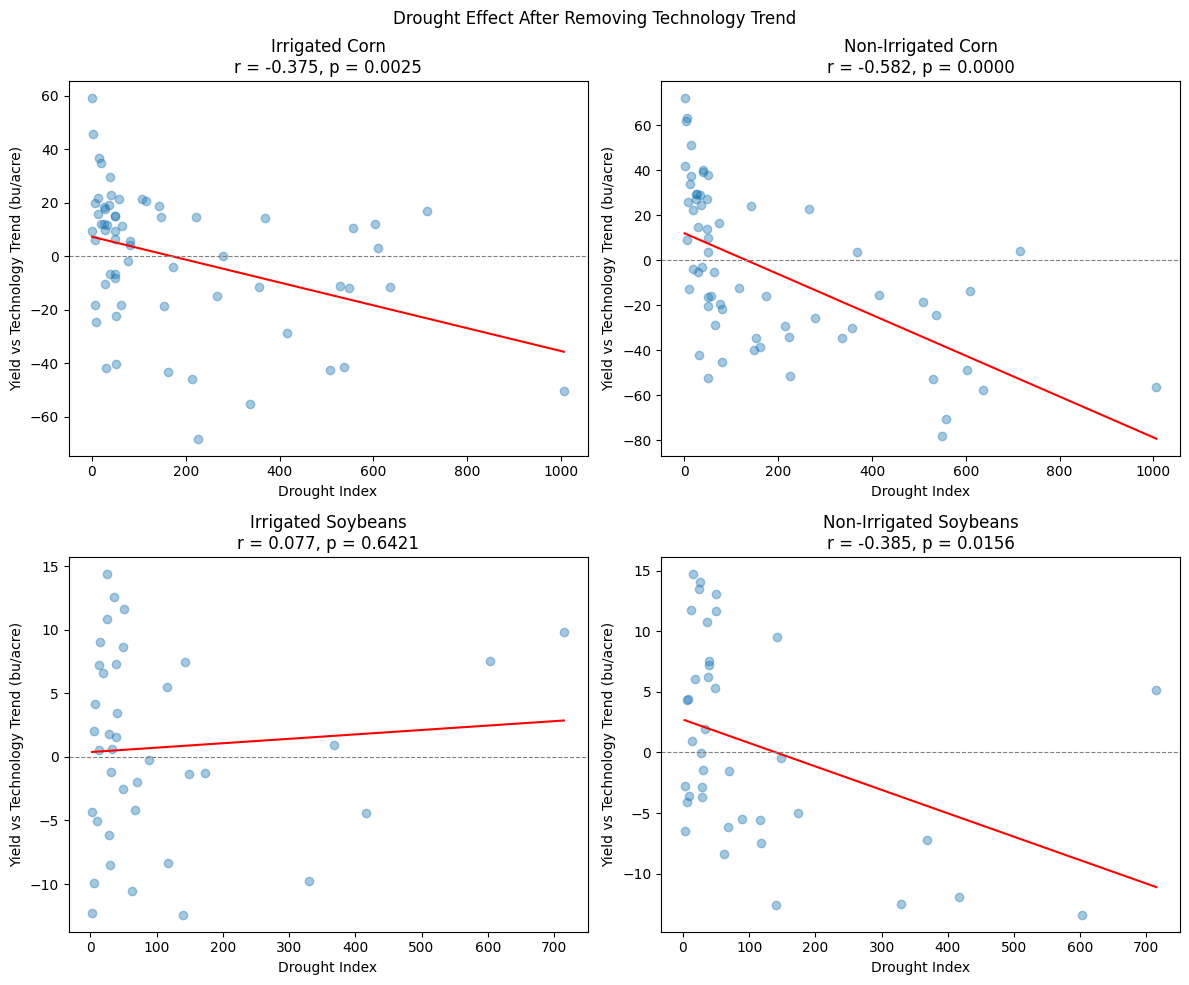

In [20]:
# Step 2: Compute residuals (actual - technology prediction)
df_tech_detrended = df_crop_yields.copy()

for crop, (slope, intercept) in tech_trends.items():
    predicted = slope * df_tech_detrended['Year'] + intercept
    df_tech_detrended[crop] = df_tech_detrended[crop] - predicted

# Step 3: Correlate residuals with drought
df_merged_tech = df_tech_detrended.merge(df_drought_index, on=['Year', 'State'])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
crop_labels = [
    ('Corn_Irrigated', 'Irrigated Corn'),
    ('Corn_NonIrrigated', 'Non-Irrigated Corn'),
    ('Soy_Irrigated', 'Irrigated Soybeans'),
    ('Soy_NonIrrigated', 'Non-Irrigated Soybeans'),
]

for ax, (col, label) in zip(axes.flatten(), crop_labels):
    subset = df_merged_tech[['Drought Index', col]].dropna()
    x, y = subset['Drought Index'], subset[col]
    slope, intercept, r, p, _ = stats.linregress(x, y)

    ax.scatter(x, y, alpha=0.4)
    ax.plot(np.sort(x), slope * np.sort(x) + intercept, color='red')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    ax.set_xlabel('Drought Index')
    ax.set_ylabel('Yield vs Technology Trend (bu/acre)')

plt.suptitle('Drought Effect After Removing Technology Trend')
plt.tight_layout()
plt.show()


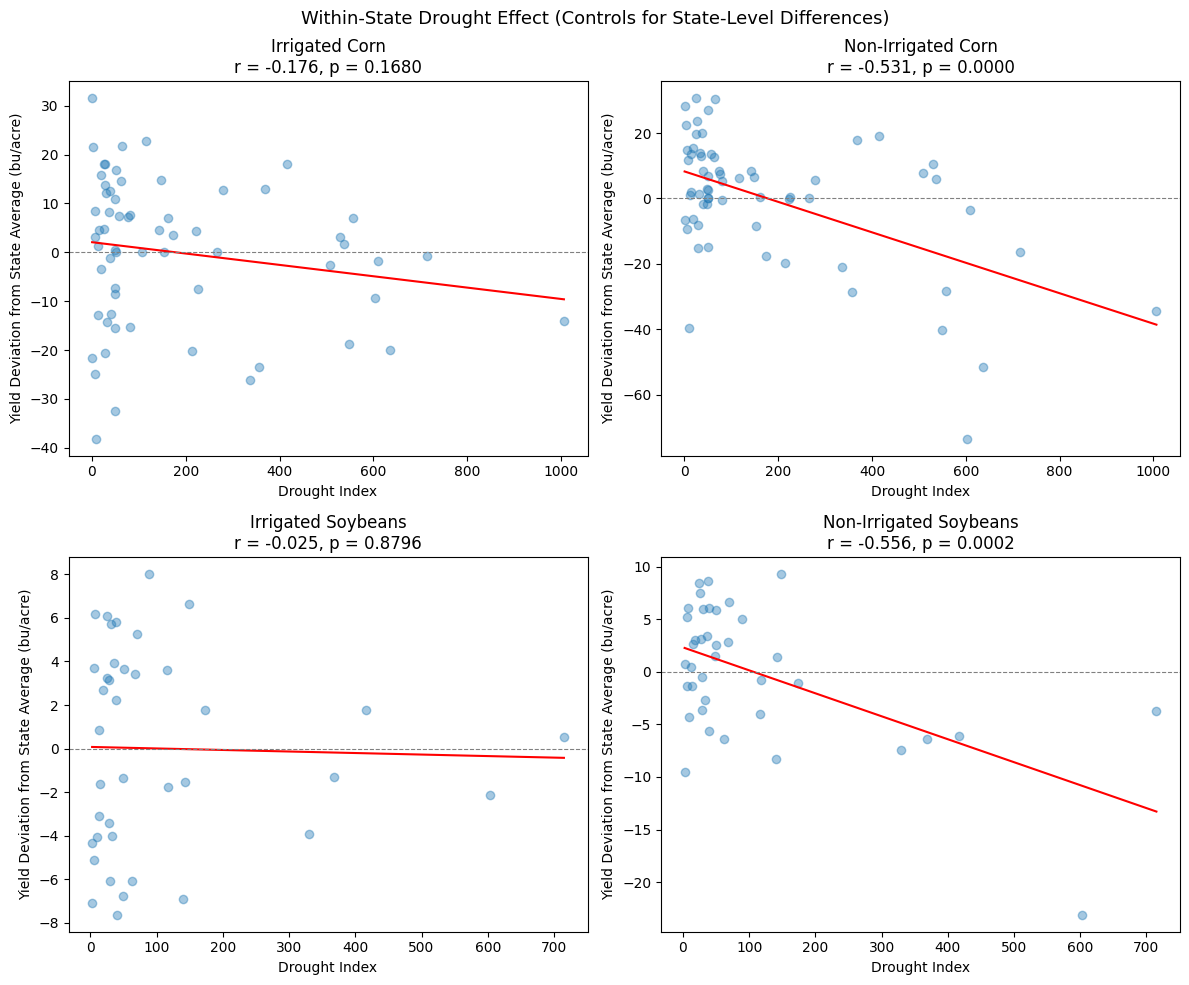

In [34]:
# Within-state correlation for all 4 crop types
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
crop_labels = [
    ('Corn_Irrigated', 'Irrigated Corn'),
    ('Corn_NonIrrigated', 'Non-Irrigated Corn'),
    ('Soy_Irrigated', 'Irrigated Soybeans'),
    ('Soy_NonIrrigated', 'Non-Irrigated Soybeans'),
]

for ax, (col, label) in zip(axes.flatten(), crop_labels):
    state_means = df_combined.groupby('State')[col].mean()
    
    df_within = df_combined.copy()
    df_within['Deviation'] = df_within.apply(
        lambda row: row[col] - state_means[row['State']]
        if row['State'] in state_means.index else None, axis=1
    )
    
    subset = df_within[['Drought Index', 'Deviation']].dropna()
    if len(subset) < 5:
        continue
    r, p = stats.pearsonr(subset['Drought Index'], subset['Deviation'])
    slope, intercept, _, _, _ = stats.linregress(subset['Drought Index'], subset['Deviation'])
    
    ax.scatter(subset['Drought Index'], subset['Deviation'], alpha=0.4)
    ax.plot(np.sort(subset['Drought Index']), slope * np.sort(subset['Drought Index']) + intercept, color='red')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    ax.set_xlabel('Drought Index')
    ax.set_ylabel('Yield Deviation from State Average (bu/acre)')

plt.suptitle('Within-State Drought Effect (Controls for State-Level Differences)', fontsize=13)
plt.tight_layout()
plt.show()


In [21]:
newDf = pd.read_csv('corn, soybeans, wheat, state, irr vs non-irr, planted and yield.csv')
newDf.head()

,Program,Year,Period,Week Ending,Geo Level,State,State ANSI,Ag District,Ag District Code,County,...,Zip Code,Region,watershed_code,Watershed,Commodity,Data Item,Domain,Domain Category,Value,CV (%)
0,SURVEY,2024,YEAR,NaN,STATE,DELAWARE,10,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN, IRRIGATED - YIELD, MEASURED IN BU...",TOTAL,NOT SPECIFIED,208.3,NaN
1,SURVEY,2024,YEAR,NaN,STATE,DELAWARE,10,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN, NON-IRRIGATED - YIELD, MEASURED I...",TOTAL,NOT SPECIFIED,130.8,NaN
2,SURVEY,2024,YEAR,NaN,STATE,DELAWARE,10,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CORN,"CORN, IRRIGATED - ACRES PLANTED",TOTAL,NOT SPECIFIED,"85,000",NaN
3,SURVEY,2024,YEAR,NaN,STATE,DELAWARE,10,NaN,NaN,NaN,...,NaN,NaN,0,NaN,CORN,"CORN, NON-IRRIGATED - ACRES PLANTED",TOTAL,NOT SPECIFIED,"80,000",NaN
4,SURVEY,2024,YEAR,NaN,STATE,DELAWARE,10,NaN,NaN,NaN,...,NaN,NaN,0,NaN,SOYBEANS,"SOYBEANS, IRRIGATED - ACRES PLANTED",TOTAL,NOT SPECIFIED,"59,000",NaN


In [22]:
# Clean the new dataset
df_new = newDf[['Year', 'State', 'Commodity', 'Data Item', 'Value']].copy()
df_new['Value'] = pd.to_numeric(df_new['Value'].astype(str).str.replace(',', ''), errors='coerce')

# Separate acres planted from yield
df_acres = df_new[df_new['Data Item'].str.contains('ACRES PLANTED')]
df_acres_clean = df_acres.groupby(['Year', 'State', 'Data Item'])['Value'].mean().reset_index()
print(df_acres_clean['Data Item'].unique())
print(df_acres_clean.head(10))


<StringArray>
[    'SOYBEANS, IRRIGATED - ACRES PLANTED',
 'SOYBEANS, NON-IRRIGATED - ACRES PLANTED',
        'WHEAT, IRRIGATED - ACRES PLANTED',
    'WHEAT, NON-IRRIGATED - ACRES PLANTED',
         'CORN, IRRIGATED - ACRES PLANTED',
     'CORN, NON-IRRIGATED - ACRES PLANTED']
Length: 6, dtype: str
   Year       State                                Data Item      Value
0  2000    ARKANSAS      SOYBEANS, IRRIGATED - ACRES PLANTED  1930000.0
1  2000    ARKANSAS  SOYBEANS, NON-IRRIGATED - ACRES PLANTED  1420000.0
2  2000  CALIFORNIA         WHEAT, IRRIGATED - ACRES PLANTED   485000.0
3  2000  CALIFORNIA     WHEAT, NON-IRRIGATED - ACRES PLANTED   150000.0
4  2000    COLORADO          CORN, IRRIGATED - ACRES PLANTED   950000.0
5  2000    COLORADO      CORN, NON-IRRIGATED - ACRES PLANTED   400000.0
6  2000    COLORADO         WHEAT, IRRIGATED - ACRES PLANTED   229000.0
7  2000    COLORADO     WHEAT, NON-IRRIGATED - ACRES PLANTED  2319000.0
8  2000       IDAHO         WHEAT, IRRIGATED - ACRES

In [23]:
# Pivot acres planted into clean columns
df_acres_pivot = df_acres.pivot_table(index=['Year', 'State'], columns='Data Item', values='Value').reset_index()
df_acres_pivot.columns.name = None
df_acres_pivot.columns = [c.replace('CORN, ', 'corn_').replace('SOYBEANS, ', 'Soy_').replace('WHEAT, ', 'Wheat_')
                           .replace('IRRIGATED - ACRES PLANTED', 'Irr_Acres')
                           .replace('NON-IRRIGATED - ACRES PLANTED', 'NonIrr_Acres')
                           .replace(', ', '_').strip() for c in df_acres_pivot.columns]
df_acres_pivot['State'] = df_acres_pivot['State'].str.title().map({v.title(): k for k, v in {
    'AL':'Alabama','AK':'Alaska','AZ':'Arizona','AR':'Arkansas','CA':'California',
    'CO':'Colorado','CT':'Connecticut','DE':'Delaware','FL':'Florida','GA':'Georgia',
    'HI':'Hawaii','ID':'Idaho','IL':'Illinois','IN':'Indiana','IA':'Iowa','KS':'Kansas',
    'KY':'Kentucky','LA':'Louisiana','ME':'Maine','MD':'Maryland','MA':'Massachusetts',
    'MI':'Michigan','MN':'Minnesota','MS':'Mississippi','MO':'Missouri','MT':'Montana',
    'NE':'Nebraska','NV':'Nevada','NH':'New Hampshire','NJ':'New Jersey','NM':'New Mexico',
    'NY':'New York','NC':'North Carolina','ND':'North Dakota','OH':'Ohio','OK':'Oklahoma',
    'OR':'Oregon','PA':'Pennsylvania','RI':'Rhode Island','SC':'South Carolina',
    'SD':'South Dakota','TN':'Tennessee','TX':'Texas','UT':'Utah','VT':'Vermont',
    'VA':'Virginia','WA':'Washington','WV':'West Virginia','WI':'Wisconsin','WY':'Wyoming'
}.items()})
print(df_acres_pivot.columns.tolist())
print(df_acres_pivot.head())


['Year', 'State', 'corn_Irr_Acres', 'corn_NON-Irr_Acres', 'Soy_Irr_Acres', 'Soy_NON-Irr_Acres', 'Wheat_Irr_Acres', 'Wheat_NON-Irr_Acres']
   Year State  corn_Irr_Acres  corn_NON-Irr_Acres  Soy_Irr_Acres  \
0  2000    AR             NaN                 NaN      1930000.0   
1  2000    CA             NaN                 NaN            NaN   
2  2000    CO        950000.0            400000.0            NaN   
3  2000    ID             NaN                 NaN            NaN   
4  2000    KS       1710000.0           1740000.0       398000.0   

   Soy_NON-Irr_Acres  Wheat_Irr_Acres  Wheat_NON-Irr_Acres  
0          1420000.0              NaN                  NaN  
1                NaN         485000.0             150000.0  
2                NaN         229000.0            2319000.0  
3                NaN         700000.0             640000.0  
4          2552000.0         540000.0            9260000.0  


In [24]:
# Merge acres with drought index
df_acres_drought = df_acres_pivot.merge(df_drought_index, on=['Year', 'State'])

acre_cols = [c for c in df_acres_pivot.columns if 'Acres' in c]
print("Correlation between Drought Index and Acres Planted:")
for col in acre_cols:
    subset = df_acres_drought[['Drought Index', col]].dropna()
    if len(subset) < 5:
        continue
    r, p = stats.pearsonr(subset['Drought Index'], subset[col])
    print(f"  {col}: r = {r:.3f}, p = {p:.4f}")


Correlation between Drought Index and Acres Planted:
  corn_Irr_Acres: r = -0.021, p = 0.8060
  corn_NON-Irr_Acres: r = -0.042, p = 0.6393
  Soy_Irr_Acres: r = 0.108, p = 0.3717
  Soy_NON-Irr_Acres: r = 0.173, p = 0.1491
  Wheat_Irr_Acres: r = -0.158, p = 0.0841
  Wheat_NON-Irr_Acres: r = -0.220, p = 0.0123


In [25]:
# Extract wheat yield from new dataset and compare drought sensitivity
df_yield_new = df_new[df_new['Data Item'].str.contains('YIELD')]
df_yield_pivot = df_yield_new.pivot_table(index=['Year', 'State'], columns='Data Item', values='Value').reset_index()
df_yield_pivot.columns.name = None
df_yield_pivot['State'] = df_acres_pivot['State'].values if len(df_yield_pivot) == len(df_acres_pivot) else df_yield_pivot['State']

# Map state names to abbreviations same as above
df_yield_pivot['State'] = df_yield_pivot['State'].str.title().map({v.title(): k for k, v in {
    'AL':'Alabama','AK':'Alaska','AZ':'Arizona','AR':'Arkansas','CA':'California',
    'CO':'Colorado','CT':'Connecticut','DE':'Delaware','FL':'Florida','GA':'Georgia',
    'HI':'Hawaii','ID':'Idaho','IL':'Illinois','IN':'Indiana','IA':'Iowa','KS':'Kansas',
    'KY':'Kentucky','LA':'Louisiana','ME':'Maine','MD':'Maryland','MA':'Massachusetts',
    'MI':'Michigan','MN':'Minnesota','MS':'Mississippi','MO':'Missouri','MT':'Montana',
    'NE':'Nebraska','NV':'Nevada','NH':'New Hampshire','NJ':'New Jersey','NM':'New Mexico',
    'NY':'New York','NC':'North Carolina','ND':'North Dakota','OH':'Ohio','OK':'Oklahoma',
    'OR':'Oregon','PA':'Pennsylvania','RI':'Rhode Island','SC':'South Carolina',
    'SD':'South Dakota','TN':'Tennessee','TX':'Texas','UT':'Utah','VT':'Vermont',
    'VA':'Virginia','WA':'Washington','WV':'West Virginia','WI':'Wisconsin','WY':'Wyoming'
}.items()})

df_yield_drought = df_yield_pivot.merge(df_drought_index, on=['Year', 'State'])
print("Drought vs Yield correlations (all crops):")
for col in df_yield_pivot.columns[2:]:
    subset = df_yield_drought[['Drought Index', col]].dropna()
    if len(subset) < 5:
        continue
    r, p = stats.pearsonr(subset['Drought Index'], subset[col])
    sig = '**' if p < 0.05 else ''
    print(f"  {col[:50]}: r = {r:.3f}, p = {p:.4f} {sig}")


Drought vs Yield correlations (all crops):
  CORN, GRAIN, IRRIGATED - YIELD, MEASURED IN BU / A: r = -0.344, p = 0.0000 **
  CORN, GRAIN, NON-IRRIGATED - YIELD, MEASURED IN BU: r = -0.538, p = 0.0000 **
  SOYBEANS, IRRIGATED - YIELD, MEASURED IN BU / ACRE: r = -0.086, p = 0.4750 
  SOYBEANS, NON-IRRIGATED - YIELD, MEASURED IN BU / : r = -0.362, p = 0.0019 **
  WHEAT, IRRIGATED - YIELD, MEASURED IN BU / ACRE: r = 0.026, p = 0.7781 
  WHEAT, NON-IRRIGATED - YIELD, MEASURED IN BU / ACR: r = -0.249, p = 0.0044 **


In [27]:
from sklearn.linear_model import LinearRegression

for crop in ['Corn_Irrigated', 'Corn_NonIrrigated', 'Soy_Irrigated', 'Soy_NonIrrigated']:
    subset = df_combined[['Year', 'Drought Index', crop]].dropna()
    X = subset[['Year', 'Drought Index']]
    y = subset[crop]
    model = LinearRegression().fit(X, y)
    print(f"{crop}:")
    print(f"  Technology effect: +{model.coef_[0]:.2f} bu/acre per year")
    print(f"  Drought effect:    {model.coef_[1]:.4f} bu/acre per drought index unit")
    print(f"  Max drought impact (index=1000): {model.coef_[1] * 1000:.1f} bu/acre")
    print(f"  R² = {model.score(X, y):.3f}\n")


Corn_Irrigated:
  Technology effect: +3.10 bu/acre per year
  Drought effect:    -0.0436 bu/acre per drought index unit
  Max drought impact (index=1000): -43.6 bu/acre
  R² = 0.347

Corn_NonIrrigated:
  Technology effect: +3.30 bu/acre per year
  Drought effect:    -0.0926 bu/acre per drought index unit
  Max drought impact (index=1000): -92.6 bu/acre
  R² = 0.472

Soy_Irrigated:
  Technology effect: +0.53 bu/acre per year
  Drought effect:    0.0040 bu/acre per drought index unit
  Max drought impact (index=1000): 4.0 bu/acre
  R² = 0.100

Soy_NonIrrigated:
  Technology effect: +0.73 bu/acre per year
  Drought effect:    -0.0195 bu/acre per drought index unit
  Max drought impact (index=1000): -19.5 bu/acre
  R² = 0.289



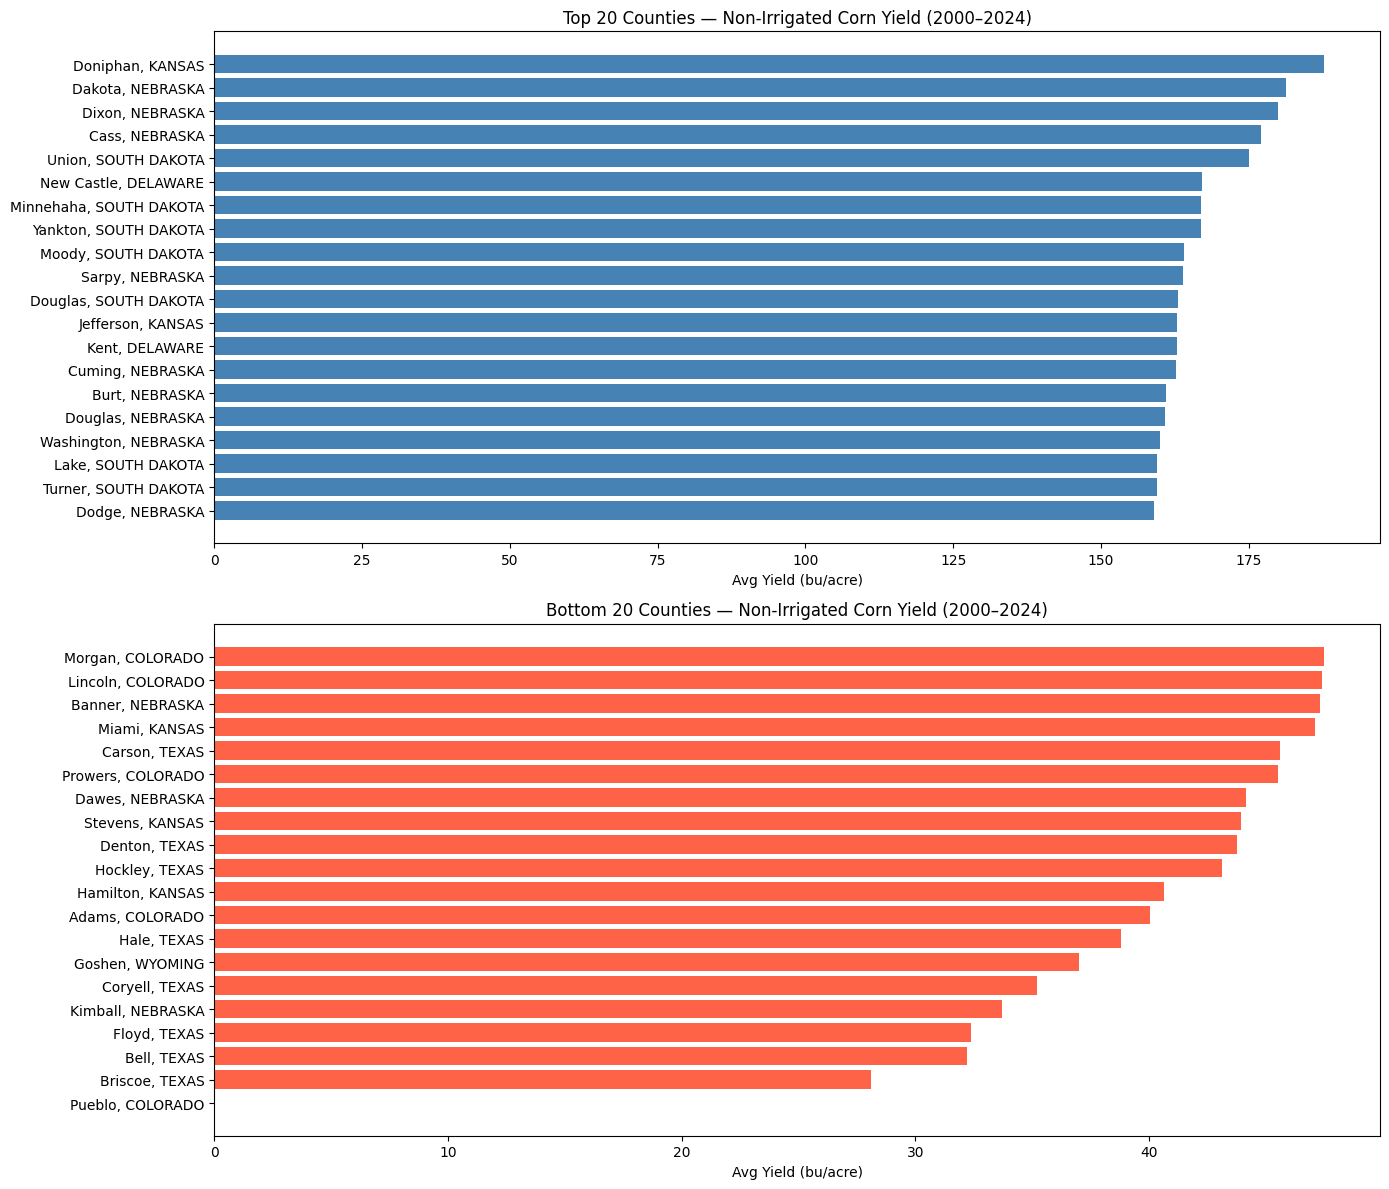

Total counties with data: 301
Highest yield: Doniphan, KANSAS — 187.8 bu/acre
Lowest yield:  Pueblo, COLORADO — 0.0 bu/acre


In [28]:
# County-level yield efficiency
df_county = df_crops[['State', 'County', 'Data Item', 'Value']].copy()
df_county = df_county[df_county['County'] != 'OTHER COUNTIES']
df_county['Value'] = pd.to_numeric(df_county['Value'], errors='coerce')

# Focus on non-irrigated corn (most data available)
df_county_corn = df_county[df_county['Data Item'].str.contains('CORN, GRAIN, NON-IRRIGATED - YIELD')]
df_county_avg = df_county_corn.groupby(['State', 'County'])['Value'].mean().reset_index()
df_county_avg.columns = ['State', 'County', 'Avg_Yield']
df_county_avg['County_Label'] = df_county_avg['County'].str.title() + ', ' + df_county_avg['State']
df_county_avg = df_county_avg.dropna().sort_values('Avg_Yield', ascending=False)

top20 = df_county_avg.head(20)
bot20 = df_county_avg.tail(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

axes[0].barh(top20['County_Label'], top20['Avg_Yield'], color='steelblue')
axes[0].set_title('Top 20 Counties — Non-Irrigated Corn Yield (2000–2024)')
axes[0].set_xlabel('Avg Yield (bu/acre)')
axes[0].invert_yaxis()

axes[1].barh(bot20['County_Label'], bot20['Avg_Yield'], color='tomato')
axes[1].set_title('Bottom 20 Counties — Non-Irrigated Corn Yield (2000–2024)')
axes[1].set_xlabel('Avg Yield (bu/acre)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Total counties with data: {len(df_county_avg)}")
print(f"Highest yield: {df_county_avg.iloc[0]['County_Label']} — {df_county_avg.iloc[0]['Avg_Yield']:.1f} bu/acre")
print(f"Lowest yield:  {df_county_avg.iloc[-1]['County_Label']} — {df_county_avg.iloc[-1]['Avg_Yield']:.1f} bu/acre")


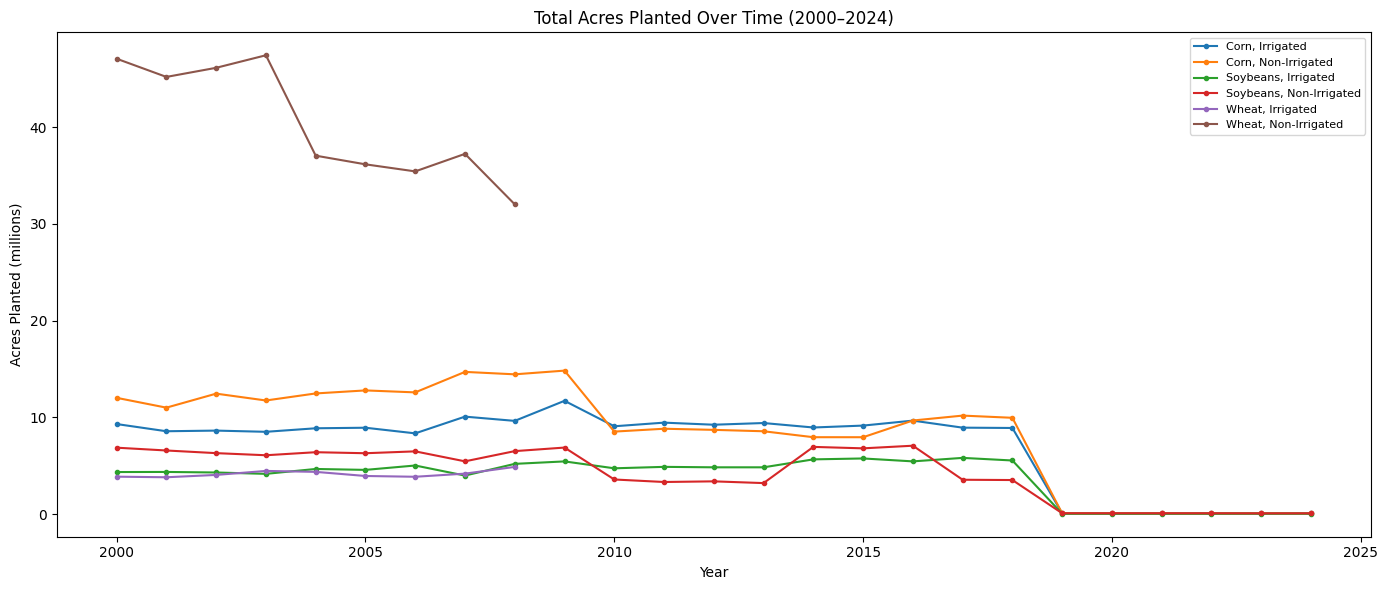

In [35]:
# Acres planted over time by crop
df_acres_time = df_acres.groupby(['Year', 'Data Item'])['Value'].sum().reset_index()
df_acres_time['Value'] = pd.to_numeric(df_acres_time['Value'].astype(str).str.replace(',', ''), errors='coerce')

fig, ax = plt.subplots(figsize=(14, 6))
for item, group in df_acres_time.groupby('Data Item'):
    label = item.replace(' - ACRES PLANTED', '').title()
    ax.plot(group['Year'], group['Value'] / 1e6, label=label, marker='o', markersize=3)

ax.set_title('Total Acres Planted Over Time (2000–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Acres Planted (millions)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()


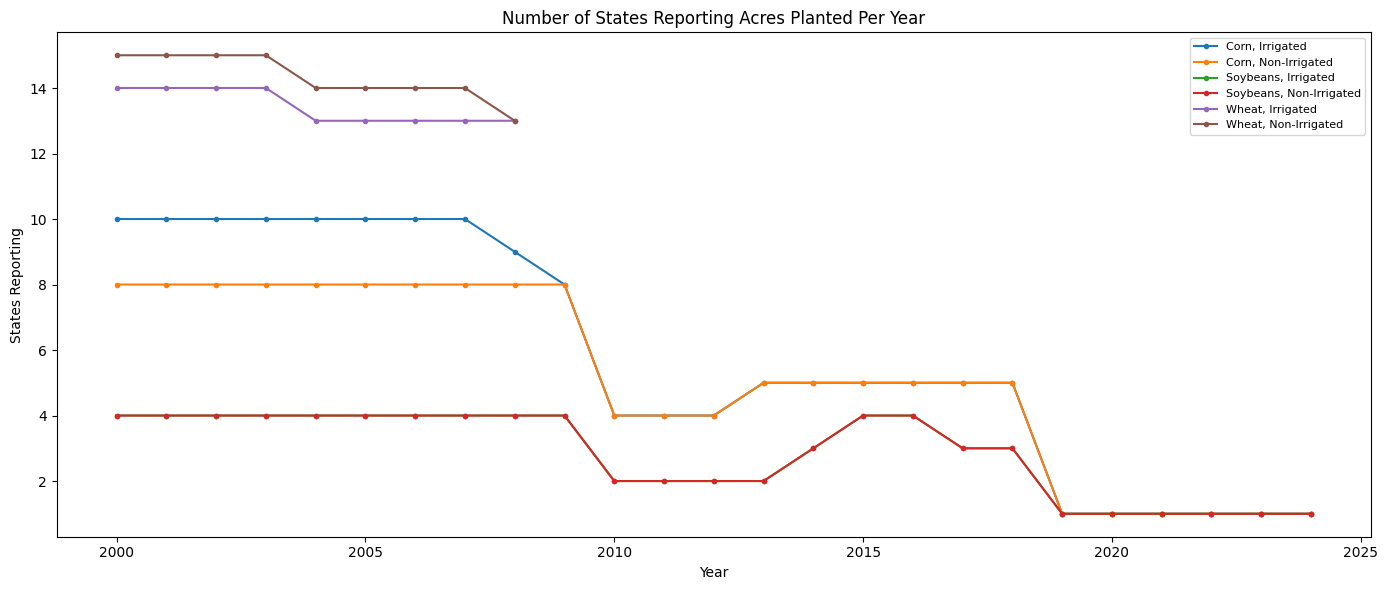

In [37]:
# Check how many states report data per year per crop
df_acres_coverage = df_acres.groupby(['Year', 'Data Item'])['Value'].count().reset_index()
df_acres_coverage.columns = ['Year', 'Data Item', 'States Reporting']

fig, ax = plt.subplots(figsize=(14, 6))
for item, group in df_acres_coverage.groupby('Data Item'):
    label = item.replace(' - ACRES PLANTED', '').title()
    ax.plot(group['Year'], group['States Reporting'], label=label, marker='o', markersize=3)

ax.set_title('Number of States Reporting Acres Planted Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('States Reporting')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


/tmp/ipykernel_203711/2577862914.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=order)


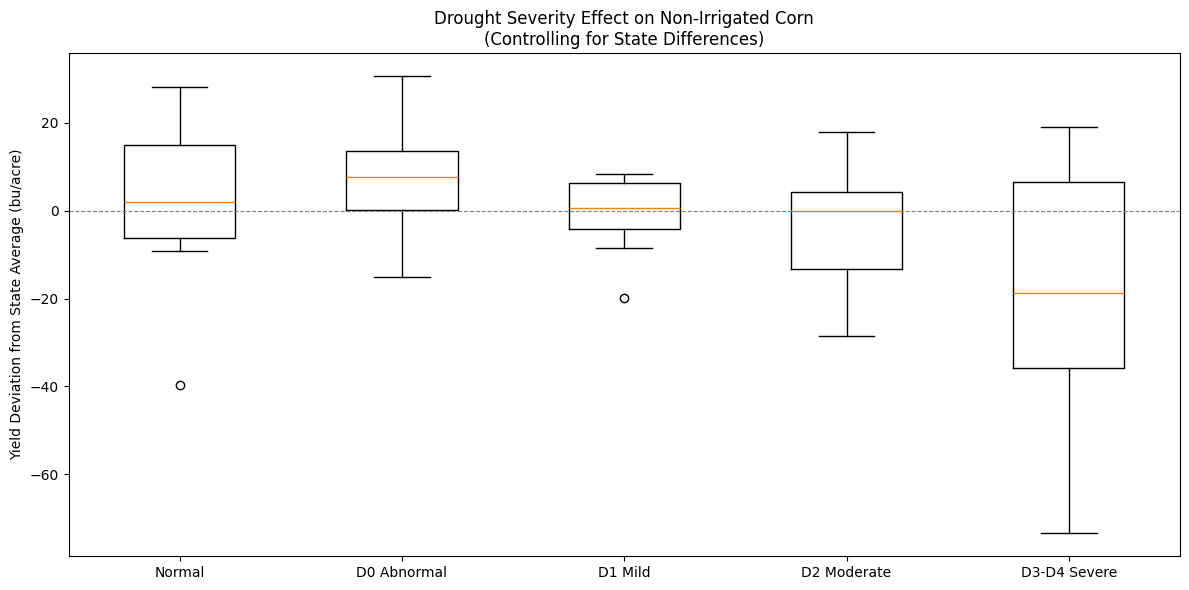

Average yield deviation by drought severity:
  Normal: 4.3 bu/acre (n=17)
  D0 Abnormal: 8.6 bu/acre (n=21)
  D1 Mild: -0.9 bu/acre (n=7)
  D2 Moderate: -3.8 bu/acre (n=6)
  D3-D4 Severe: -18.8 bu/acre (n=12)


In [43]:
# Re-aggregate drought categories from scratch
df_drought_cats = df_drought[df_drought['MapDate'].astype(str).str[:4].astype(int).between(2000, 2024)].copy()
df_drought_cats['Year'] = df_drought_cats['MapDate'].astype(str).str[:4].astype(int)
df_drought_cats = df_drought_cats[~df_drought_cats['State'].isin(['DC', 'PR'])]
df_drought_cats = df_drought_cats.groupby(['Year', 'State'])[['D0', 'D1', 'D2', 'D3', 'D4']].mean().reset_index()

def classify_drought(row):
    if row['D3'] + row['D4'] > 20:
        return 'D3-D4 Severe'
    elif row['D2'] > 20:
        return 'D2 Moderate'
    elif row['D1'] > 20:
        return 'D1 Mild'
    elif row['D0'] > 20:
        return 'D0 Abnormal'
    else:
        return 'Normal'

df_drought_cats['Category'] = df_drought_cats.apply(classify_drought, axis=1)
df_sev_merged2 = df_crop_yields.merge(df_drought_cats, on=['Year', 'State'])

# Use within-state deviation to remove geographic bias
state_means = df_sev_merged2.groupby('State')['Corn_NonIrrigated'].mean()
df_sev_merged2['Deviation'] = df_sev_merged2.apply(
    lambda row: row['Corn_NonIrrigated'] - state_means[row['State']]
    if row['State'] in state_means.index else None, axis=1
)

order = ['Normal', 'D0 Abnormal', 'D1 Mild', 'D2 Moderate', 'D3-D4 Severe']
groups = [df_sev_merged2[df_sev_merged2['Category'] == cat]['Deviation'].dropna() for cat in order]

plt.figure(figsize=(12, 6))
plt.boxplot(groups, labels=order)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.ylabel('Yield Deviation from State Average (bu/acre)')
plt.title('Drought Severity Effect on Non-Irrigated Corn\n(Controlling for State Differences)')
plt.tight_layout()
plt.show()

print("Average yield deviation by drought severity:")
for cat, group in zip(order, groups):
    print(f"  {cat}: {group.mean():.1f} bu/acre (n={len(group)})")
